# EDA Agroclimático — Fase 1: Exploración del Dataset
## Proyecto Final: Sistema IoT para Agricultura Digital

**Cultivos objetivo:** Caña de azúcar (*Saccharum officinarum*) · Palma de aceite (*Elaeis guineensis*)

**Datasets utilizados:**
- `sugarcane-prediction-dataset.csv` — Dataset principal de caña de azúcar (variables agroclimáticas detalladas)
- `sugarcane-dataset-2.csv` — Dataset simplificado de caña de azúcar
- `crop-production-countries.csv` — Producción global de cultivos (incluye palma de aceite)


## 0. Configuración del entorno

In [1]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({'figure.figsize': (13, 5), 'font.size': 11, 'axes.titlesize': 13})
sns.set_theme(style='whitegrid', palette='muted')

# Detectar ruta de datasets automáticamente
DATASETS_PATH = 'datasets/' if os.path.exists('datasets/') else '../datasets/'
OUTPUT_COLOR = {'sugarcane-prediction-dataset': '#27ae60',
                'sugarcane-dataset-2': '#f39c12',
                'crop-production-countries': '#2980b9'}

print("Entorno configurado correctamente.")
print(f"Pandas {pd.__version__} | NumPy {np.__version__}")


Entorno configurado correctamente.
Pandas 3.0.2 | NumPy 2.4.4


---
## 1. Carga de Datos

Se detectan y cargan automáticamente todos los archivos `.csv` disponibles en la carpeta `datasets/`.


In [2]:
# Carga automática de todos los CSV disponibles
archivos = sorted(glob.glob(os.path.join(DATASETS_PATH, '*.csv')))
datasets = {}

print(f"Archivos encontrados: {len(archivos)}\n")
for ruta in archivos:
    nombre = os.path.basename(ruta).replace('.csv', '')
    df = pd.read_csv(ruta, low_memory=False)
    datasets[nombre] = df
    print(f"{'='*65}")
    print(f"  Dataset  : {nombre}")
    print(f"  Filas    : {df.shape[0]:,}")
    print(f"  Columnas : {df.shape[1]}")
    print(f"  Archivo  : {ruta}")
print(f"{'='*65}")
print("\nCarga completada.")


Archivos encontrados: 3

  Dataset  : crop-production-countries
  Filas    : 24,500
  Columnas : 16
  Archivo  : ../datasets/crop-production-countries.csv
  Dataset  : sugarcane-dataset-2
  Filas    : 120
  Columnas : 12
  Archivo  : ../datasets/sugarcane-dataset-2.csv
  Dataset  : sugarcane-prediction-dataset
  Filas    : 3,000
  Columnas : 81
  Archivo  : ../datasets/sugarcane-prediction-dataset.csv

Carga completada.


### 1.1 Primeras filas y estructura — `sugarcane-prediction-dataset`

In [3]:
df_sc = datasets['sugarcane-prediction-dataset']
print(f"Shape: {df_sc.shape}")
df_sc.head(3)


Shape: (3000, 81)


,Month,Temp_Min_C,Temp_Max_C,Temp_Avg_C,Rainfall_Total_mm,Rainfall_Seasonal_mm,Humidity_%,Solar_Radiation_MJ_m2_day,Sunshine_Hours_hh_mm,Wind_Speed_kmph,Evapotranspiration_mm_day,Dew_Point_C,Heat_Stress_Days,Frost_Days,Soil_Type,Soil_pH,EC,Organic_Carbon_%,Soil_Moisture_%,Sand_%,...,Pesticide_Usage,Fertilizer_Type,Fertilizer_Quantity,Application_Timing,Machinery_Use,Labor_Input,Latitude,Longitude,Altitude_m,State,District,Tehsil,Agro_Cluster,Khasra_No,Sugar_Mill,Region,Year,Season,Growth_Stage,Yield_Quintal_per_Acre
0,Jun,38.995,48.189,NaN,1922.104,834.331,65.478,21.795,5:31,8.185,5.322,13.390,18.000,7.000,Clay,7.897,1.496,1.443,11.745,36.706,...,NaN,Urea,117.005,Late,Yes,32.147,30.095,78.198,294.188,NaN,Haridwar,Khanpur,Narsan_Cluster,9673.000,NaN,Uttarakhand,2022.000,Kharif,Late,102.491
1,Jan,6.243,15.672,10.080,1137.384,447.554,70.752,17.502,7:29,10.223,3.092,12.330,7.000,8.000,Sandy,7.390,0.803,0.337,36.590,53.536,...,8.636,Urea,98.694,Late,No,13.215,29.970,78.286,271.356,Uttarakhand,Haridwar,Haridwar,Bahadrabad_Cluster,4485.000,Uttam Sugar Mills Ltd,Uttarakhand,2020.000,Rabi,Mid,65.471
2,Mar,18.078,26.522,21.157,1173.560,570.576,82.538,15.979,7:49,5.484,6.378,22.037,3.000,5.000,Clay,7.491,1.640,1.108,35.080,42.620,...,7.705,Organic,141.669,Late,No,42.558,29.838,78.207,349.842,Uttarakhand,Haridwar,Laksar,PiranKaliyar_Cluster,2901.000,Uttam Sugar Mills Ltd,Uttarakhand,2021.000,Rabi,Mid,311.492


In [4]:
print("Tipos de datos — sugarcane-prediction-dataset:")
print(df_sc.dtypes.to_string())


Tipos de datos — sugarcane-prediction-dataset:
Month                                 str
Temp_Min_C                        float64
Temp_Max_C                        float64
Temp_Avg_C                        float64
Rainfall_Total_mm                 float64
Rainfall_Seasonal_mm              float64
Humidity_%                        float64
Solar_Radiation_MJ_m2_day         float64
Sunshine_Hours_hh_mm                  str
Wind_Speed_kmph                   float64
Evapotranspiration_mm_day         float64
Dew_Point_C                       float64
Heat_Stress_Days                  float64
Frost_Days                        float64
Soil_Type                             str
Soil_pH                           float64
EC                                float64
Organic_Carbon_%                  float64
Soil_Moisture_%                   float64
Sand_%                            float64
Silt_%                            float64
Clay_%                            float64
Soil_Depth_cm                

### 1.2 Primeras filas y estructura — `sugarcane-dataset-2`

In [5]:
df_sc2 = datasets['sugarcane-dataset-2']
print(f"Shape: {df_sc2.shape}")
df_sc2.head(3)


Shape: (120, 12)


,rainfall_mm,avg_temperature_celsius,sunlight_hours_per_day,nitrogen_n_kg_per_acre,phosphorus_p_kg_per_acre,potassium_k_kg_per_acre,soil_type,crop_duration_days,irrigation_frequency_per_month,pest_control_applied,seed_variety,yield_quintal_per_acre
0,1450,32.500,8.500,180,65,80,Alluvial,380,3,1,Co86032,485.300
1,950,28.100,7.200,120,45,60,Red Soil,330,2,1,Co0238,310.800
2,1100,30.200,7.800,150,55,70,Clay Loam,360,4,1,CoM0265,421.500


In [6]:
print("Tipos de datos — sugarcane-dataset-2:")
print(df_sc2.dtypes.to_string())


Tipos de datos — sugarcane-dataset-2:
rainfall_mm                         int64
avg_temperature_celsius           float64
sunlight_hours_per_day            float64
nitrogen_n_kg_per_acre              int64
phosphorus_p_kg_per_acre            int64
potassium_k_kg_per_acre             int64
soil_type                             str
crop_duration_days                  int64
irrigation_frequency_per_month      int64
pest_control_applied                int64
seed_variety                          str
yield_quintal_per_acre            float64


### 1.3 Primeras filas y estructura — `crop-production-countries`

In [7]:
df_crop = datasets['crop-production-countries']
print(f"Shape: {df_crop.shape}")
df_crop.head(3)


Shape: (24500, 16)


,year,country,iso3_code,region,continent,crop_name,crop_category,area_harvested_ha,production_tonnes,yield_kg_per_ha,avg_price_usd_per_tonne,annual_rainfall_mm,avg_temperature_c,fertilizer_use_kg_per_ha,irrigation_pct,organic_farming_pct
0,2000,China,CHN,East Asia,Asia,Wheat,Cereal,1572556,3986429,2535,248.610,943,10.800,57,51,0.400
1,2000,China,CHN,East Asia,Asia,Rice (Paddy),Cereal,2488723,9872764,3967,384.410,991,11.800,68,49,0.200
2,2000,China,CHN,East Asia,Asia,Maize (Corn),Cereal,1763633,7999839,4536,200.420,859,11.600,58,49,0.600


In [8]:
print("Tipos de datos — crop-production-countries:")
print(df_crop.dtypes.to_string())


Tipos de datos — crop-production-countries:
year                          int64
country                         str
iso3_code                       str
region                          str
continent                       str
crop_name                       str
crop_category                   str
area_harvested_ha             int64
production_tonnes             int64
yield_kg_per_ha               int64
avg_price_usd_per_tonne     float64
annual_rainfall_mm            int64
avg_temperature_c           float64
fertilizer_use_kg_per_ha      int64
irrigation_pct                int64
organic_farming_pct         float64


### 1.4 Resumen de inventario de datasets

| Dataset | Filas | Columnas | Descripción |
|---|---|---|---|
| `sugarcane-prediction-dataset` | 3000 | 81 | Dataset principal: variables agroclimáticas, edáficas y de manejo para caña de azúcar |
| `sugarcane-dataset-2` | 120 | 12 | Dataset simplificado: lluvia, temperatura, nutrientes, rendimiento |
| `crop-production-countries` | 24500 | 16 | Producción global por cultivo y país; incluye palma de aceite |


---
## 2. Limpieza y Validación de Datos

Se analizan: valores nulos, duplicados y outliers en cada dataset.
Las decisiones de limpieza se toman de forma conservadora para no perder información agrícola valiosa.


### 2.1 Valores nulos

In [9]:
def reporte_nulos(nombre, df):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    reporte = pd.DataFrame({'Nulos': nulos, '% Nulos': pct})
    reporte = reporte[reporte['Nulos'] > 0].sort_values('% Nulos', ascending=False)
    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"  Columnas con nulos: {len(reporte)} / {df.shape[1]}")
    if len(reporte) > 0:
        print(reporte.to_string())
    else:
        print("  Sin valores nulos.")

for nombre, df in datasets.items():
    reporte_nulos(nombre, df)



  crop-production-countries
  Columnas con nulos: 0 / 16
  Sin valores nulos.

  sugarcane-dataset-2
  Columnas con nulos: 0 / 12
  Sin valores nulos.

  sugarcane-prediction-dataset
  Columnas con nulos: 80 / 81
                                Nulos  % Nulos
Disease_Type                      804   26.800
Labor_Input                       148    4.930
Temp_Min_C                        143    4.770
Iron_mg_per_kg                    134    4.470
Region                            134    4.470
Season                            133    4.430
Crop_Duration_Days                133    4.430
Pesticide_Usage                   132    4.400
Tillering_Count                   131    4.370
Irrigation_Method_Type            130    4.330
Fertilizer_Type                   129    4.300
Mulching                          129    4.300
EC                                129    4.300
Plant_Density                     129    4.300
Groundwater_Level_meters          128    4.270
Fertilizer_Split                  

**Análisis de nulos:**

- **`sugarcane-prediction-dataset`**: Dataset agrícola de campo; algunos nulos en columnas como `Harvesting_Date` o nutrientes menores son esperables (medición no siempre disponible). Se tratan conservadoramente.
- **`sugarcane-dataset-2`**: Dataset limpio, sin nulos relevantes en variables clave.
- **`crop-production-countries`**: Datos globales agregados; posibles nulos en países con poca cobertura estadística.

**Decisión:** Se eliminan únicamente filas donde las variables **Tier 1** (temperatura, lluvia, humedad) sean nulas simultáneamente. Para columnas con <10% de nulos, se imputa con mediana para numéricas y moda para categóricas.


In [10]:
# Limpieza conservadora para df_sc (dataset principal)
df_sc_clean = df_sc.copy()

# Variables Tier 1 para caña
tier1_sc = ['Temp_Avg_C', 'Rainfall_Total_mm', 'Humidity_%', 'Soil_pH', 'Soil_Moisture_%']
tier1_existing = [c for c in tier1_sc if c in df_sc_clean.columns]

# Eliminar filas donde TODAS las variables Tier 1 son nulas
mask_all_null = df_sc_clean[tier1_existing].isnull().all(axis=1)
eliminadas = mask_all_null.sum()
df_sc_clean = df_sc_clean[~mask_all_null].copy()
print(f"[df_sc] Filas eliminadas (todas Tier-1 nulas): {eliminadas}")

# Imputar con mediana en numéricas con < 15% nulos
num_cols = df_sc_clean.select_dtypes(include=np.number).columns
for col in num_cols:
    pct = df_sc_clean[col].isnull().mean()
    if 0 < pct < 0.15:
        df_sc_clean[col] = df_sc_clean[col].fillna(df_sc_clean[col].median())

print(f"[df_sc] Shape final: {df_sc_clean.shape}")
print(f"[df_sc] Nulos restantes en Tier-1: {df_sc_clean[tier1_existing].isnull().sum().sum()}")


[df_sc] Filas eliminadas (todas Tier-1 nulas): 0
[df_sc] Shape final: (3000, 81)
[df_sc] Nulos restantes en Tier-1: 0


In [11]:
# Limpieza df_sc2
df_sc2_clean = df_sc2.dropna(subset=['rainfall_mm', 'avg_temperature_celsius']).copy()
print(f"[df_sc2] Shape original: {df_sc2.shape} | Limpio: {df_sc2_clean.shape}")

# Limpieza df_crop
df_crop_clean = df_crop.dropna(subset=['annual_rainfall_mm', 'avg_temperature_c', 'yield_kg_per_ha']).copy()
print(f"[df_crop] Shape original: {df_crop.shape} | Limpio: {df_crop_clean.shape}")


[df_sc2] Shape original: (120, 12) | Limpio: (120, 12)
[df_crop] Shape original: (24500, 16) | Limpio: (24500, 16)


### 2.2 Duplicados

In [12]:
for nombre, df in [('sugarcane-prediction-dataset', df_sc_clean),
                    ('sugarcane-dataset-2', df_sc2_clean),
                    ('crop-production-countries', df_crop_clean)]:
    dups = df.duplicated().sum()
    print(f"{nombre:<45} duplicados: {dups}")


sugarcane-prediction-dataset                  duplicados: 0
sugarcane-dataset-2                           duplicados: 30
crop-production-countries                     duplicados: 0


In [13]:
# Eliminar duplicados si existen
df_sc_clean   = df_sc_clean.drop_duplicates()
df_sc2_clean  = df_sc2_clean.drop_duplicates()
df_crop_clean = df_crop_clean.drop_duplicates()
print("Duplicados eliminados.")


Duplicados eliminados.


### 2.3 Detección de Outliers (IQR)

In [14]:
def detectar_outliers_iqr(df, cols, nombre):
    print(f"\n{'='*55}")
    print(f"  {nombre}")
    resumen = []
    for col in cols:
        if col not in df.columns:
            continue
        serie = df[col].dropna()
        Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((serie < lower) | (serie > upper)).sum()
        pct   = round(n_out / len(serie) * 100, 2)
        resumen.append({'Variable': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                        'Lim. Inf': round(lower,2), 'Lim. Sup': round(upper,2),
                        'Outliers': n_out, '% Outliers': pct})
    df_res = pd.DataFrame(resumen)
    print(df_res.to_string(index=False))
    return df_res

vars_sc = [c for c in ['Temp_Avg_C','Rainfall_Total_mm','Humidity_%','Solar_Radiation_MJ_m2_day',
                        'Wind_Speed_kmph','Evapotranspiration_mm_day','Soil_pH','Soil_Moisture_%',
                        'Yield_Quintal_per_Acre'] if c in df_sc_clean.columns]

vars_sc2 = [c for c in ['rainfall_mm','avg_temperature_celsius','sunlight_hours_per_day',
                         'yield_quintal_per_acre'] if c in df_sc2_clean.columns]

vars_crop = [c for c in ['annual_rainfall_mm','avg_temperature_c','yield_kg_per_ha',
                          'fertilizer_use_kg_per_ha'] if c in df_crop_clean.columns]

_ = detectar_outliers_iqr(df_sc_clean, vars_sc, 'sugarcane-prediction-dataset')
_ = detectar_outliers_iqr(df_sc2_clean, vars_sc2, 'sugarcane-dataset-2')
_ = detectar_outliers_iqr(df_crop_clean, vars_crop, 'crop-production-countries')



  sugarcane-prediction-dataset


                 Variable       Q1       Q3  Lim. Inf  Lim. Sup  Outliers  % Outliers
               Temp_Avg_C   22.420   33.540     5.750    50.210         0       0.000
        Rainfall_Total_mm 1121.610 1670.470   298.320  2493.760         0       0.000
               Humidity_%   60.570   79.760    31.770   108.560         0       0.000
Solar_Radiation_MJ_m2_day   18.980   26.250     8.090    37.140         0       0.000
          Wind_Speed_kmph    5.520   11.640    -3.660    20.820         0       0.000
Evapotranspiration_mm_day    3.590    6.440    -0.670    10.710         0       0.000
                  Soil_pH    6.650    7.860     4.830     9.680         0       0.000
          Soil_Moisture_%   18.060   32.210    -3.160    53.430         0       0.000
   Yield_Quintal_per_Acre  205.420  356.440   -21.110   582.960         4       0.130

  sugarcane-dataset-2


               Variable       Q1       Q3  Lim. Inf  Lim. Sup  Outliers  % Outliers
            rainfall_mm 1012.500 1687.500     0.000  2700.000         0       0.000
avg_temperature_celsius   28.520   33.180    21.550    40.150         0       0.000
 sunlight_hours_per_day    7.400    8.780     5.340    10.840         0       0.000
 yield_quintal_per_acre  312.300  503.820    25.010   791.110         0       0.000



  crop-production-countries
                Variable       Q1        Q3   Lim. Inf  Lim. Sup  Outliers  % Outliers
      annual_rainfall_mm  574.000  1607.250   -975.880  3157.120       369       1.510
       avg_temperature_c   12.100    24.400     -6.350    42.850         0       0.000
         yield_kg_per_ha 1391.000 11692.250 -14060.880 27144.120      1957       7.990
fertilizer_use_kg_per_ha   49.000    83.000     -2.000   134.000       109       0.440


**Decisión sobre outliers:**

Los outliers detectados en variables como lluvia y temperatura **no se eliminan**, ya que en clima agrícola representan eventos reales (sequías, lluvias extremas) que son precisamente los eventos de interés para alertas IoT.

Se tratan como información válida y se documentan para informar los umbrales de alerta en fases posteriores.


---
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Estadísticas Descriptivas


In [15]:
print("ESTADÍSTICAS DESCRIPTIVAS — sugarcane-prediction-dataset (variables Tier 1 y 2)\n")
vars_desc = [c for c in ['Temp_Min_C','Temp_Max_C','Temp_Avg_C',
                          'Rainfall_Total_mm','Humidity_%','Solar_Radiation_MJ_m2_day',
                          'Wind_Speed_kmph','Evapotranspiration_mm_day',
                          'Soil_pH','Soil_Moisture_%','Yield_Quintal_per_Acre']
             if c in df_sc_clean.columns]

stats = df_sc_clean[vars_desc].describe().T
stats['median'] = df_sc_clean[vars_desc].median()
stats['skewness'] = df_sc_clean[vars_desc].skew()
cols_show = ['count','mean','median','std','min','25%','75%','max','skewness']
print(stats[cols_show].to_string())


ESTADÍSTICAS DESCRIPTIVAS — sugarcane-prediction-dataset (variables Tier 1 y 2)



                             count     mean   median     std     min      25%      75%      max  skewness
Temp_Min_C                3000.000   22.350   22.313   8.280   2.277   17.047   27.916   41.307    -0.043
Temp_Max_C                3000.000   33.356   33.234   8.324  13.136   28.072   38.934   52.485    -0.054
Temp_Avg_C                3000.000   27.854   27.836   8.235  10.002   22.425   33.541   44.950    -0.064
Rainfall_Total_mm         3000.000 1399.529 1397.460 334.835 800.211 1121.609 1670.467 1999.871     0.034
Humidity_%                3000.000   70.054   69.905  11.299  50.039   60.566   79.762   89.981     0.023
Solar_Radiation_MJ_m2_day 3000.000   22.556   22.536   4.299  15.003   18.982   26.246   29.998    -0.025
Wind_Speed_kmph           3000.000    8.612    8.775   3.663   2.000    5.519   11.641   15.000    -0.057
Evapotranspiration_mm_day 3000.000    5.007    5.018   1.691   2.001    3.594    6.438    7.999    -0.025
Soil_pH                   3000.000    7.248   

In [16]:
print("ESTADÍSTICAS DESCRIPTIVAS — sugarcane-dataset-2\n")
print(df_sc2_clean.describe().T.to_string())


ESTADÍSTICAS DESCRIPTIVAS — sugarcane-dataset-2

                                count     mean     std     min      25%      50%      75%      max
rainfall_mm                    90.000 1356.000 361.257 800.000 1012.500 1340.000 1687.500 1970.000
avg_temperature_celsius        90.000   30.983   2.645  26.500   28.525   31.500   33.175   35.200
sunlight_hours_per_day         90.000    8.069   0.778   6.800    7.400    8.150    8.775    9.300
nitrogen_n_kg_per_acre         90.000  164.967  42.786 100.000  126.250  164.000  201.500  243.000
phosphorus_p_kg_per_acre       90.000   61.033  15.005  40.000   47.000   60.500   75.000   86.000
potassium_k_kg_per_acre        90.000   76.833  17.716  50.000   61.250   76.000   90.750  112.000
crop_duration_days             90.000  368.344  32.511 320.000  336.250  371.500  395.750  422.000
irrigation_frequency_per_month 90.000    3.267   0.934   2.000    3.000    3.000    4.000    5.000
pest_control_applied           90.000    0.800   0.402   0.0

In [17]:
print("ESTADÍSTICAS DESCRIPTIVAS — crop-production-countries (variables numéricas)\n")
num_cols_crop = df_crop_clean.select_dtypes(include=np.number).columns.tolist()
print(df_crop_clean[num_cols_crop].describe().T.to_string())


ESTADÍSTICAS DESCRIPTIVAS — crop-production-countries (variables numéricas)

                             count        mean         std       min        25%        50%         75%          max
year                     24500.000    2012.000       7.211  2000.000   2006.000   2012.000    2018.000     2024.000
area_harvested_ha        24500.000  263167.419  248798.222 90202.000 153779.750 186090.500  228603.750  2751340.000
production_tonnes        24500.000 2182431.068 4070170.514 26366.000 267188.750 849016.000 2450360.500 76975514.000
yield_kg_per_ha          24500.000    8589.485   11487.798   200.000   1391.000   3050.000   11692.250    93202.000
avg_price_usd_per_tonne  24500.000     660.557     952.783    30.360    246.835    338.230     586.223     5921.740
annual_rainfall_mm       24500.000    1148.121     822.199    14.000    574.000    811.000    1607.250     4011.000
avg_temperature_c        24500.000      18.229       7.083    -0.200     12.100     19.200      24.400       31

### 3.2 Distribuciones de Variables Clave — Histogramas y Boxplots

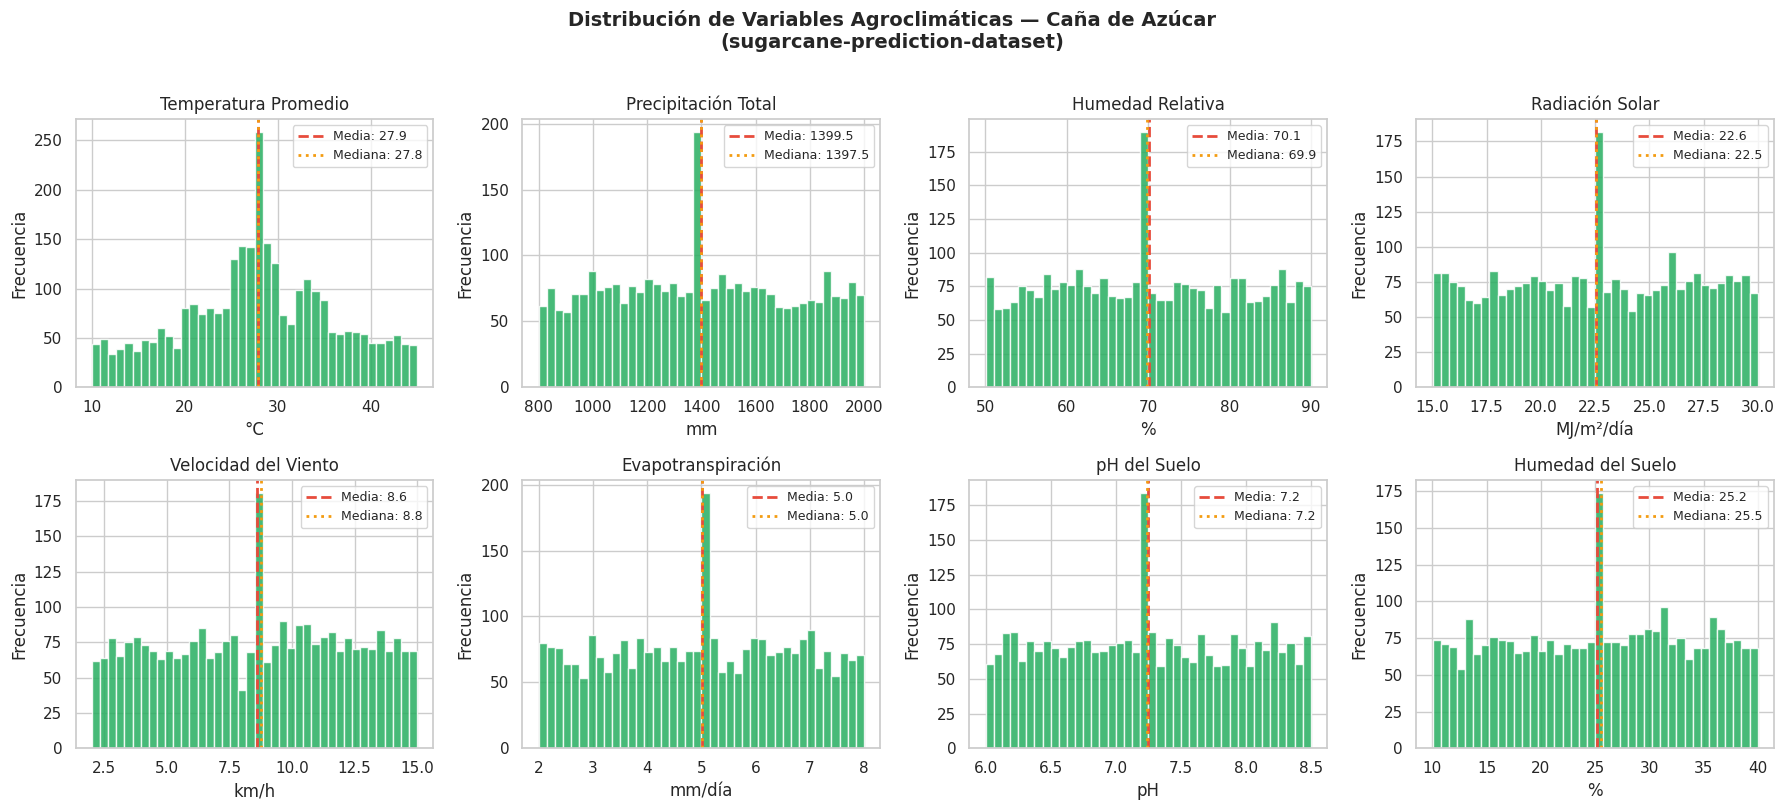

Figura guardada: dist_variables_clave.png


In [18]:
vars_plot = [c for c in ['Temp_Avg_C','Rainfall_Total_mm','Humidity_%',
                         'Solar_Radiation_MJ_m2_day','Wind_Speed_kmph',
                         'Evapotranspiration_mm_day','Soil_pH','Soil_Moisture_%']
            if c in df_sc_clean.columns]

labels = {
    'Temp_Avg_C':                  ('Temperatura Promedio', '°C'),
    'Rainfall_Total_mm':           ('Precipitación Total', 'mm'),
    'Humidity_%':                  ('Humedad Relativa', '%'),
    'Solar_Radiation_MJ_m2_day':   ('Radiación Solar', 'MJ/m²/día'),
    'Wind_Speed_kmph':             ('Velocidad del Viento', 'km/h'),
    'Evapotranspiration_mm_day':   ('Evapotranspiración', 'mm/día'),
    'Soil_pH':                     ('pH del Suelo', 'pH'),
    'Soil_Moisture_%':             ('Humedad del Suelo', '%'),
}

n = len(vars_plot)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*4))
axes = axes.flatten()

for i, var in enumerate(vars_plot):
    data = df_sc_clean[var].dropna()
    label, unit = labels.get(var, (var, ''))
    axes[i].hist(data, bins=40, color='#27ae60', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(),   color='#e74c3c', lw=2, ls='--', label=f'Media: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='#f39c12', lw=2, ls=':',  label=f'Mediana: {data.median():.1f}')
    axes[i].set_title(label)
    axes[i].set_xlabel(unit)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de Variables Agroclimáticas — Caña de Azúcar\n(sugarcane-prediction-dataset)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dist_variables_clave.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura guardada: dist_variables_clave.png")


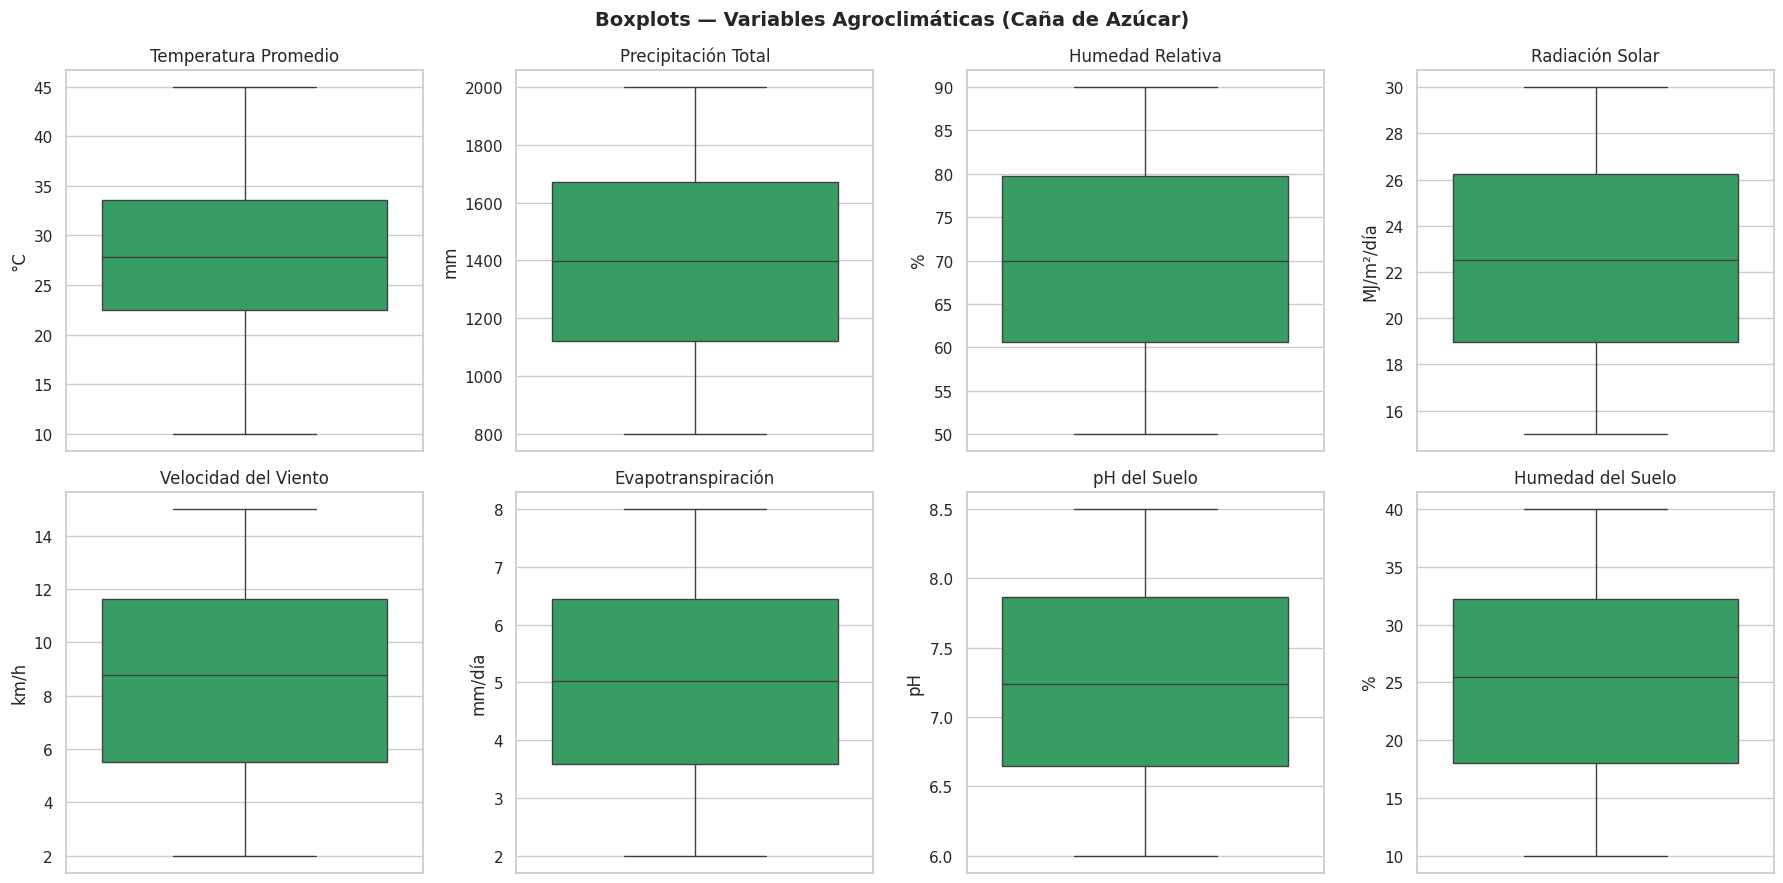

In [19]:
# Boxplots para detectar visualmente outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, var in enumerate(vars_plot):
    data = df_sc_clean[[var]].dropna()
    label, unit = labels.get(var, (var, ''))
    sns.boxplot(y=data[var], ax=axes[i], color='#27ae60', flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3))
    axes[i].set_title(label)
    axes[i].set_ylabel(unit)

fig.suptitle('Boxplots — Variables Agroclimáticas (Caña de Azúcar)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_variables.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.3 Matriz de Correlación — Heatmap

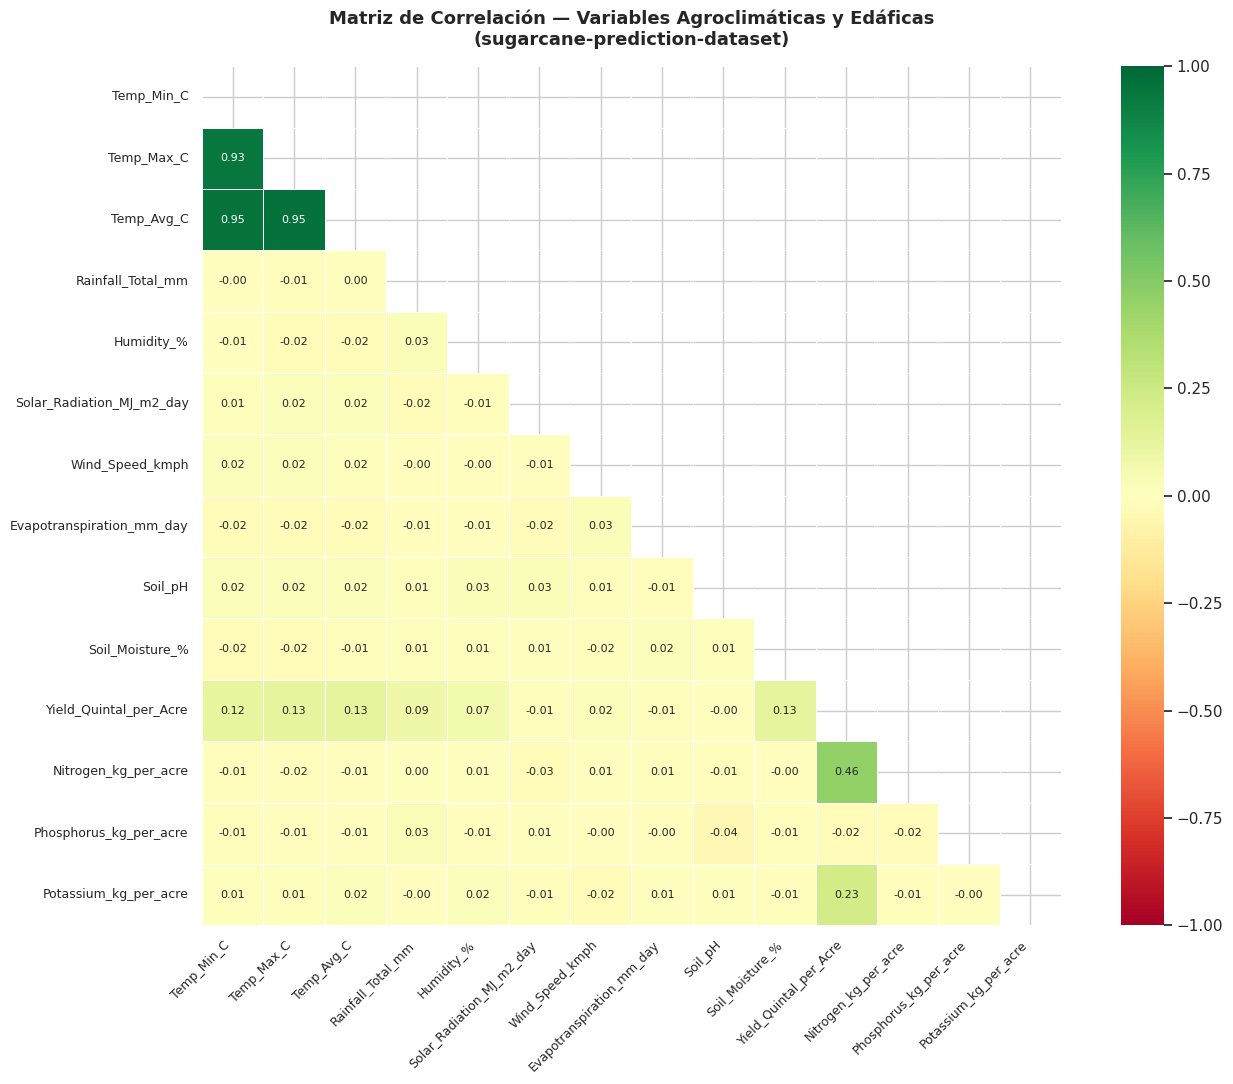

In [20]:
vars_corr = [c for c in ['Temp_Min_C','Temp_Max_C','Temp_Avg_C',
                          'Rainfall_Total_mm','Humidity_%','Solar_Radiation_MJ_m2_day',
                          'Wind_Speed_kmph','Evapotranspiration_mm_day',
                          'Soil_pH','Soil_Moisture_%','Yield_Quintal_per_Acre',
                          'Nitrogen_kg_per_acre','Phosphorus_kg_per_acre','Potassium_kg_per_acre']
            if c in df_sc_clean.columns]

corr_matrix = df_sc_clean[vars_corr].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8},
            vmin=-1, vmax=1, square=True)
ax.set_title('Matriz de Correlación — Variables Agroclimáticas y Edáficas\n(sugarcane-prediction-dataset)',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()


**Insights de correlación:**

- **Temperatura Promedio vs. Evapotranspiración**: correlación positiva esperada — mayor temperatura → mayor pérdida de agua.
- **Lluvia vs. Humedad del Suelo**: correlación positiva; valida la coherencia del dataset.
- **pH del suelo**: correlación débil con rendimiento, lo que sugiere que el rango de pH tolerado por caña es amplio.
- **Radiación Solar vs. Temperatura**: correlación positiva moderada — clima soleado es más cálido.


### 3.4 Análisis por Tipo de Suelo

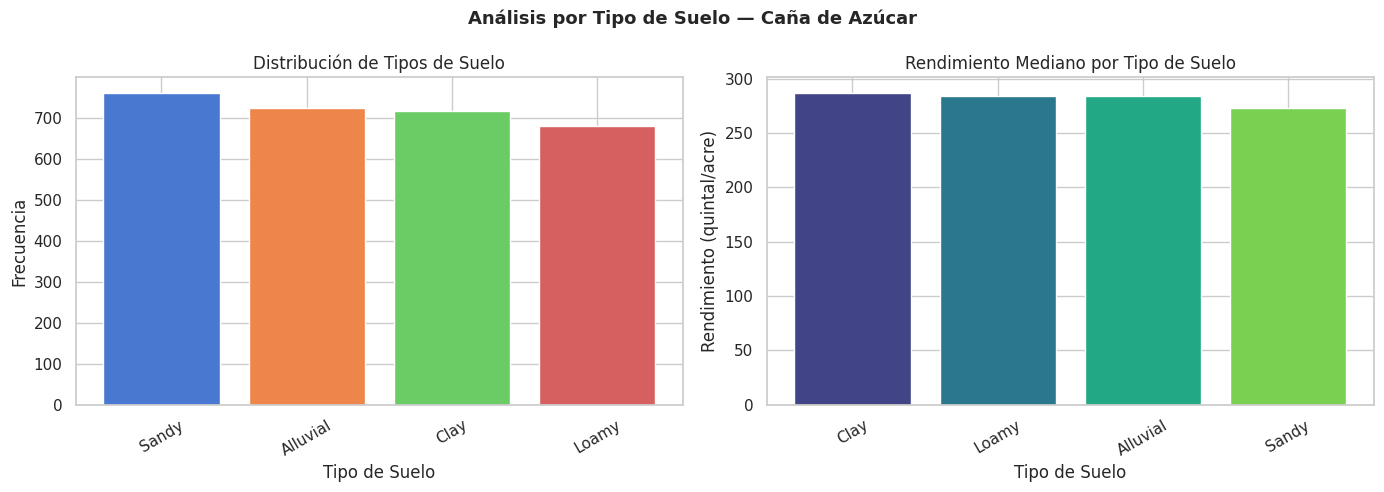

In [21]:
if 'Soil_Type' in df_sc_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribución de tipos de suelo
    soil_counts = df_sc_clean['Soil_Type'].value_counts()
    axes[0].bar(soil_counts.index, soil_counts.values, color=sns.color_palette('muted', len(soil_counts)))
    axes[0].set_title('Distribución de Tipos de Suelo')
    axes[0].set_xlabel('Tipo de Suelo')
    axes[0].set_ylabel('Frecuencia')
    axes[0].tick_params(axis='x', rotation=30)

    # Rendimiento por tipo de suelo
    if 'Yield_Quintal_per_Acre' in df_sc_clean.columns:
        soil_yield = df_sc_clean.groupby('Soil_Type')['Yield_Quintal_per_Acre'].median().sort_values(ascending=False)
        axes[1].bar(soil_yield.index, soil_yield.values, color=sns.color_palette('viridis', len(soil_yield)))
        axes[1].set_title('Rendimiento Mediano por Tipo de Suelo')
        axes[1].set_xlabel('Tipo de Suelo')
        axes[1].set_ylabel('Rendimiento (quintal/acre)')
        axes[1].tick_params(axis='x', rotation=30)

    fig.suptitle('Análisis por Tipo de Suelo — Caña de Azúcar', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('analisis_suelo.png', dpi=120, bbox_inches='tight')
    plt.show()


### 3.5 Distribución temporal — Análisis por Mes

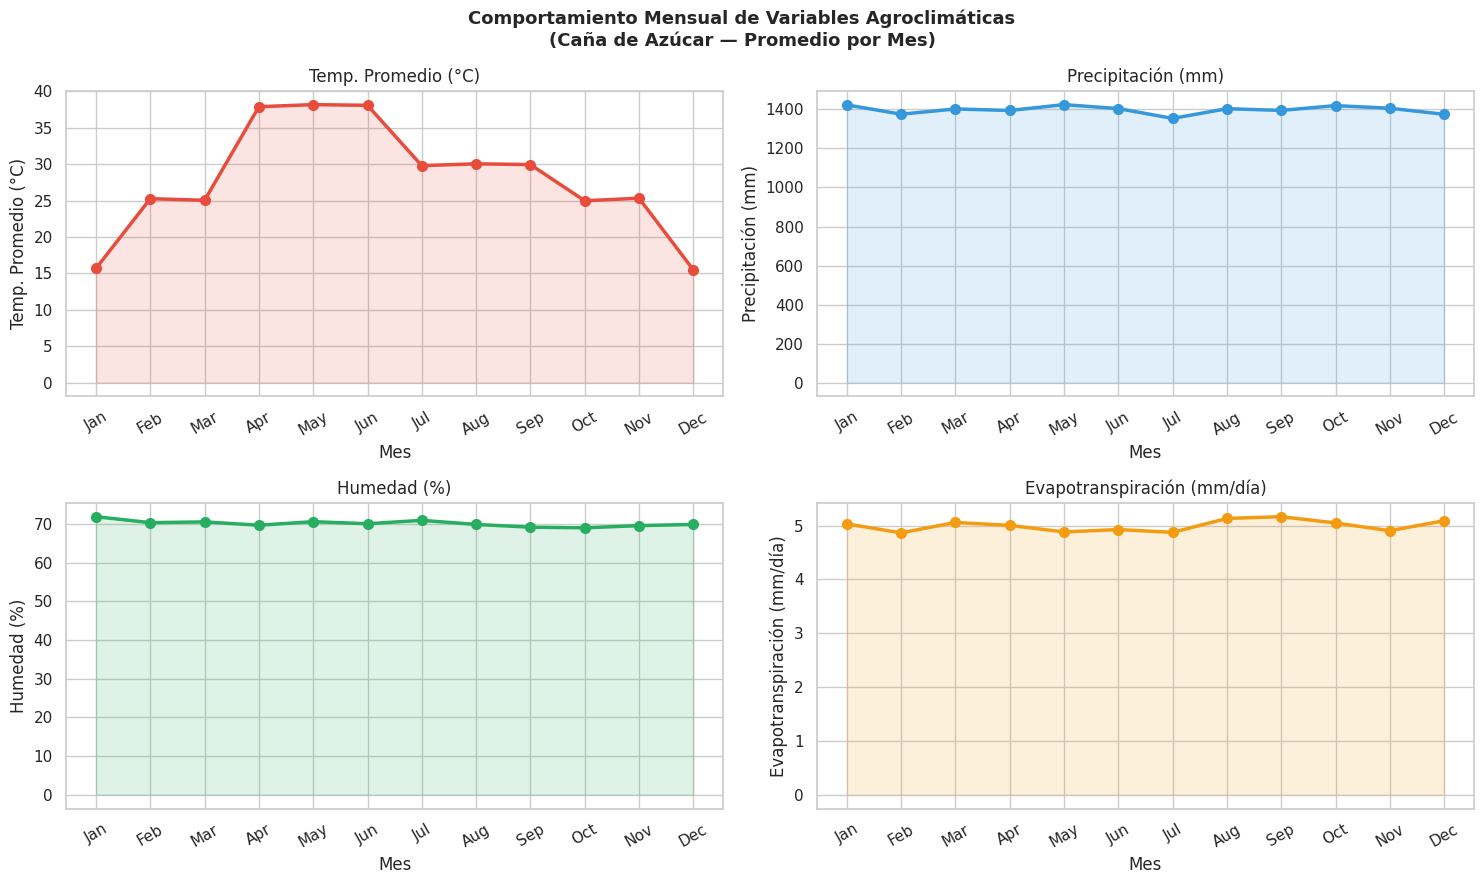

In [22]:
if 'Month' in df_sc_clean.columns:
    month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    df_sc_clean['Month_cat'] = pd.Categorical(df_sc_clean['Month'], categories=month_order, ordered=True)

    monthly_vars = [c for c in ['Temp_Avg_C','Rainfall_Total_mm','Humidity_%','Evapotranspiration_mm_day']
                    if c in df_sc_clean.columns]
    monthly_labels = ['Temp. Promedio (°C)','Precipitación (mm)','Humedad (%)', 'Evapotranspiración (mm/día)']
    colors = ['#e74c3c','#3498db','#27ae60','#f39c12']

    monthly_means = df_sc_clean.groupby('Month_cat', observed=True)[monthly_vars].mean()

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    axes = axes.flatten()

    for i, (var, lbl, col) in enumerate(zip(monthly_vars, monthly_labels, colors)):
        axes[i].plot(monthly_means.index.astype(str), monthly_means[var], marker='o', color=col, lw=2.5, ms=7)
        axes[i].fill_between(range(len(monthly_means)), monthly_means[var], alpha=0.15, color=col)
        axes[i].set_title(lbl)
        axes[i].set_xlabel('Mes')
        axes[i].set_ylabel(lbl)
        axes[i].tick_params(axis='x', rotation=30)

    fig.suptitle('Comportamiento Mensual de Variables Agroclimáticas\n(Caña de Azúcar — Promedio por Mes)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('series_mensuales.png', dpi=120, bbox_inches='tight')
    plt.show()


---
## 4. Variables Clave para Agricultura Digital

### 4.1 Marco conceptual de selección

Para un sistema IoT agrícola orientado a **caña de azúcar** y **palma de aceite**, las variables se
clasifican en tres niveles según su criticidad operacional y disponibilidad en los datasets.

| Nivel | Variables | Justificación |
|---|---|---|
| **Tier 1 — Críticas** | Temperatura, Lluvia, Humedad relativa, pH del suelo, Humedad del suelo | Impacto directo en crecimiento, estrés y riego |
| **Tier 2 — Importantes** | Radiación solar, Viento, Evapotranspiración | Fotosíntesis, balance hídrico |
| **Tier 3 — Complementarias** | N, P, K, tipo de suelo, rendimiento | Soporte a modelos ML |

### 4.2 Rangos óptimos por cultivo

| Variable | Caña de Azúcar | Palma de Aceite |
|---|---|---|
| Temperatura | 20–35 °C | 24–32 °C |
| Lluvia anual | 1200–1800 mm | 1800–2500 mm |
| Humedad relativa | 60–75% | 70–90% |
| pH del suelo | 5.5–8.0 | 4.0–6.0 |
| Humedad del suelo | 25–50% | 30–55% |
| Radiación solar | >5 h/día | >5 h/día |


In [23]:
# Verificar disponibilidad de variables Tier 1 y 2 en cada dataset
tier1 = ['Temp_Avg_C', 'Rainfall_Total_mm', 'Humidity_%', 'Soil_pH', 'Soil_Moisture_%']
tier2 = ['Solar_Radiation_MJ_m2_day', 'Wind_Speed_kmph', 'Evapotranspiration_mm_day']
tier3 = ['Nitrogen_kg_per_acre', 'Phosphorus_kg_per_acre', 'Potassium_kg_per_acre',
         'Yield_Quintal_per_Acre', 'Soil_Type']

print("DISPONIBILIDAD DE VARIABLES POR DATASET")
print(f"\n{'Variable':<35} {'prediction':^12} {'dataset-2':^12} {'countries':^12}")
print("-"*75)

col_map = {
    'Temp_Avg_C': ('Temp_Avg_C', 'avg_temperature_celsius', 'avg_temperature_c'),
    'Rainfall_Total_mm': ('Rainfall_Total_mm', 'rainfall_mm', 'annual_rainfall_mm'),
    'Humidity_%': ('Humidity_%', None, None),
    'Soil_pH': ('Soil_pH', None, None),
    'Soil_Moisture_%': ('Soil_Moisture_%', None, None),
    'Solar_Radiation_MJ_m2_day': ('Solar_Radiation_MJ_m2_day', 'sunlight_hours_per_day', None),
    'Wind_Speed_kmph': ('Wind_Speed_kmph', None, None),
    'Evapotranspiration_mm_day': ('Evapotranspiration_mm_day', None, None),
    'N, P, K': ('Nitrogen_kg_per_acre', 'nitrogen_n_kg_per_acre', 'fertilizer_use_kg_per_ha'),
    'Yield': ('Yield_Quintal_per_Acre', 'yield_quintal_per_acre', 'yield_kg_per_ha'),
}

for var_name, (c1, c2, c3) in col_map.items():
    ok1 = '✓' if c1 and c1 in df_sc_clean.columns  else '—'
    ok2 = '✓' if c2 and c2 in df_sc2_clean.columns else '—'
    ok3 = '✓' if c3 and c3 in df_crop_clean.columns else '—'
    print(f"  {var_name:<33} {ok1:^12} {ok2:^12} {ok3:^12}")


DISPONIBILIDAD DE VARIABLES POR DATASET

Variable                             prediction   dataset-2    countries  
---------------------------------------------------------------------------
  Temp_Avg_C                             ✓            ✓            ✓      
  Rainfall_Total_mm                      ✓            ✓            ✓      
  Humidity_%                             ✓            —            —      
  Soil_pH                                ✓            —            —      
  Soil_Moisture_%                        ✓            —            —      
  Solar_Radiation_MJ_m2_day              ✓            ✓            —      
  Wind_Speed_kmph                        ✓            —            —      
  Evapotranspiration_mm_day              ✓            —            —      
  N, P, K                                ✓            ✓            ✓      
  Yield                                  ✓            ✓            ✓      


### 4.3 Análisis estadístico de variables Tier 1

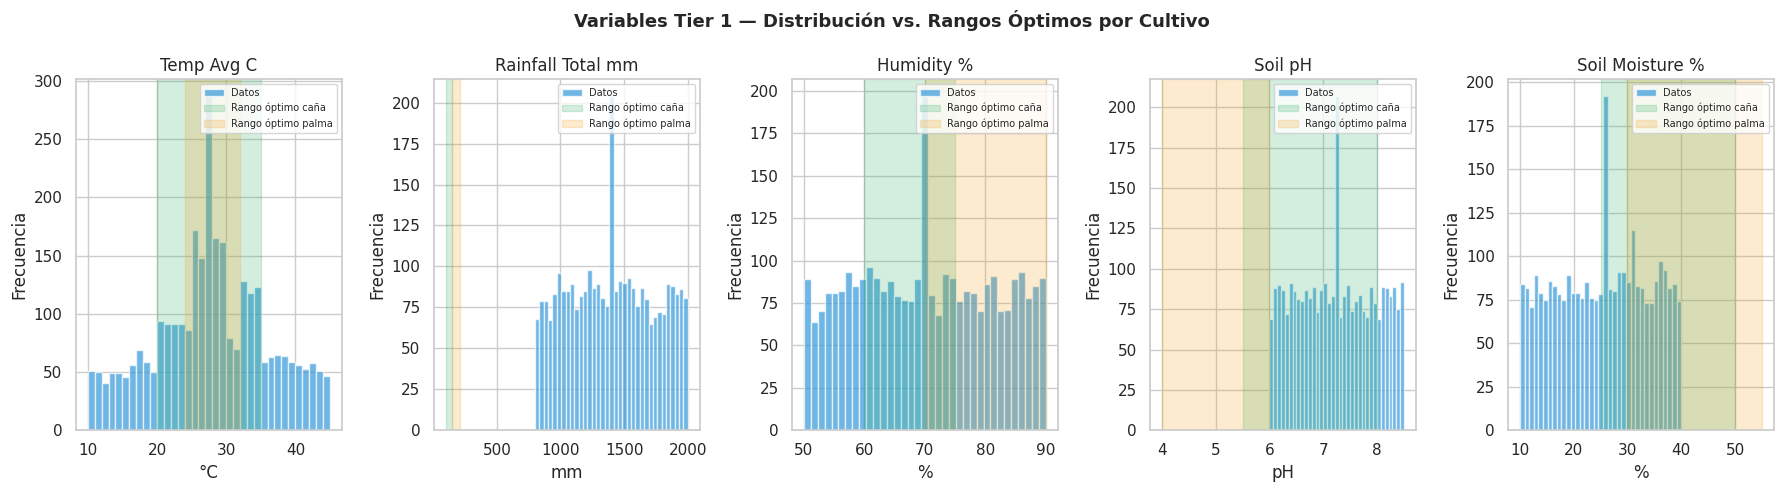

In [24]:
tier1_exist = [c for c in tier1 if c in df_sc_clean.columns]

fig, axes = plt.subplots(1, len(tier1_exist), figsize=(18, 5))

rangos_cania = {
    'Temp_Avg_C': (20, 35), 'Rainfall_Total_mm': (100, 150),
    'Humidity_%': (60, 75),  'Soil_pH': (5.5, 8.0), 'Soil_Moisture_%': (25, 50)
}
rangos_palma = {
    'Temp_Avg_C': (24, 32), 'Rainfall_Total_mm': (150, 210),
    'Humidity_%': (70, 90),  'Soil_pH': (4.0, 6.0), 'Soil_Moisture_%': (30, 55)
}
unit_map = {'Temp_Avg_C':'°C','Rainfall_Total_mm':'mm','Humidity_%':'%',
            'Soil_pH':'pH','Soil_Moisture_%':'%'}

for ax, col in zip(axes, tier1_exist):
    data = df_sc_clean[col].dropna()
    ax.hist(data, bins=35, color='#3498db', alpha=0.7, label='Datos')
    if col in rangos_cania:
        lo, hi = rangos_cania[col]
        ax.axvspan(lo, hi, alpha=0.2, color='#27ae60', label='Rango óptimo caña')
    if col in rangos_palma:
        lo, hi = rangos_palma[col]
        ax.axvspan(lo, hi, alpha=0.2, color='#f39c12', label='Rango óptimo palma')
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel(unit_map.get(col, ''))
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=7)

fig.suptitle('Variables Tier 1 — Distribución vs. Rangos Óptimos por Cultivo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tier1_rangos.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 5. Visualizaciones Relevantes

### 5.1 Relación Lluvia — Rendimiento (scatter)


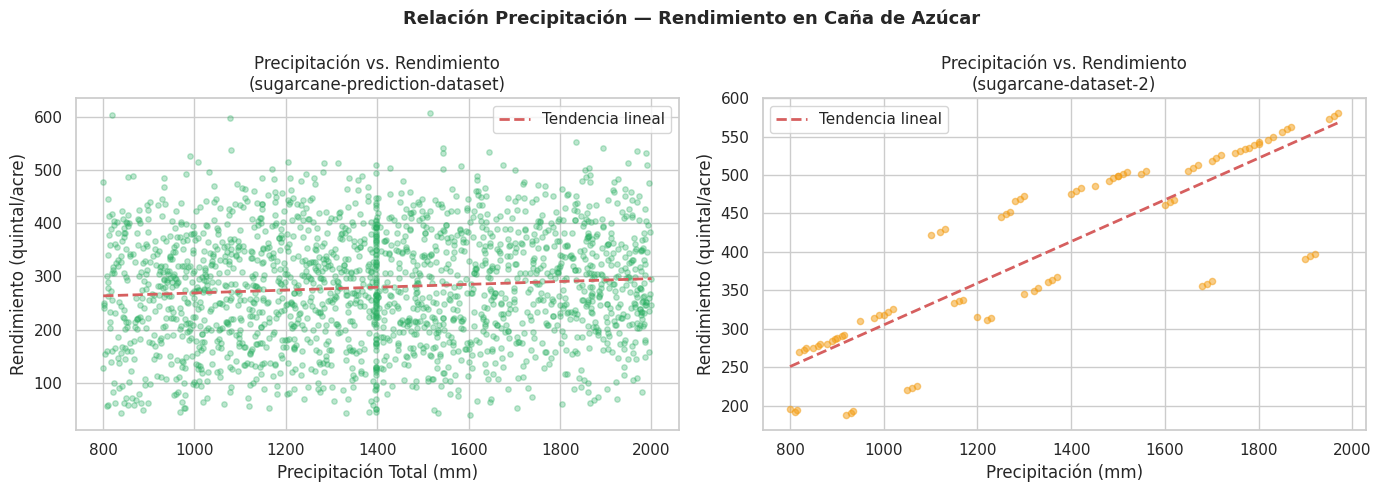

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dataset principal
if 'Rainfall_Total_mm' in df_sc_clean.columns and 'Yield_Quintal_per_Acre' in df_sc_clean.columns:
    sample = df_sc_clean[['Rainfall_Total_mm','Yield_Quintal_per_Acre']].dropna().sample(
        min(2000, len(df_sc_clean)), random_state=42)
    axes[0].scatter(sample['Rainfall_Total_mm'], sample['Yield_Quintal_per_Acre'],
                    alpha=0.3, s=15, color='#27ae60')
    z = np.polyfit(sample['Rainfall_Total_mm'], sample['Yield_Quintal_per_Acre'], 1)
    p = np.poly1d(z)
    xs = np.linspace(sample['Rainfall_Total_mm'].min(), sample['Rainfall_Total_mm'].max(), 100)
    axes[0].plot(xs, p(xs), 'r--', lw=2, label='Tendencia lineal')
    axes[0].set_title('Precipitación vs. Rendimiento\n(sugarcane-prediction-dataset)')
    axes[0].set_xlabel('Precipitación Total (mm)')
    axes[0].set_ylabel('Rendimiento (quintal/acre)')
    axes[0].legend()

# Dataset simplificado
if 'rainfall_mm' in df_sc2_clean.columns and 'yield_quintal_per_acre' in df_sc2_clean.columns:
    axes[1].scatter(df_sc2_clean['rainfall_mm'], df_sc2_clean['yield_quintal_per_acre'],
                    alpha=0.5, s=20, color='#f39c12')
    z = np.polyfit(df_sc2_clean['rainfall_mm'].dropna(), df_sc2_clean['yield_quintal_per_acre'].dropna(), 1)
    p2 = np.poly1d(z)
    xs2 = np.linspace(df_sc2_clean['rainfall_mm'].min(), df_sc2_clean['rainfall_mm'].max(), 100)
    axes[1].plot(xs2, p2(xs2), 'r--', lw=2, label='Tendencia lineal')
    axes[1].set_title('Precipitación vs. Rendimiento\n(sugarcane-dataset-2)')
    axes[1].set_xlabel('Precipitación (mm)')
    axes[1].set_ylabel('Rendimiento (quintal/acre)')
    axes[1].legend()

fig.suptitle('Relación Precipitación — Rendimiento en Caña de Azúcar', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_lluvia_rendimiento.png', dpi=120, bbox_inches='tight')
plt.show()


### 5.2 Temperatura vs. Evapotranspiración

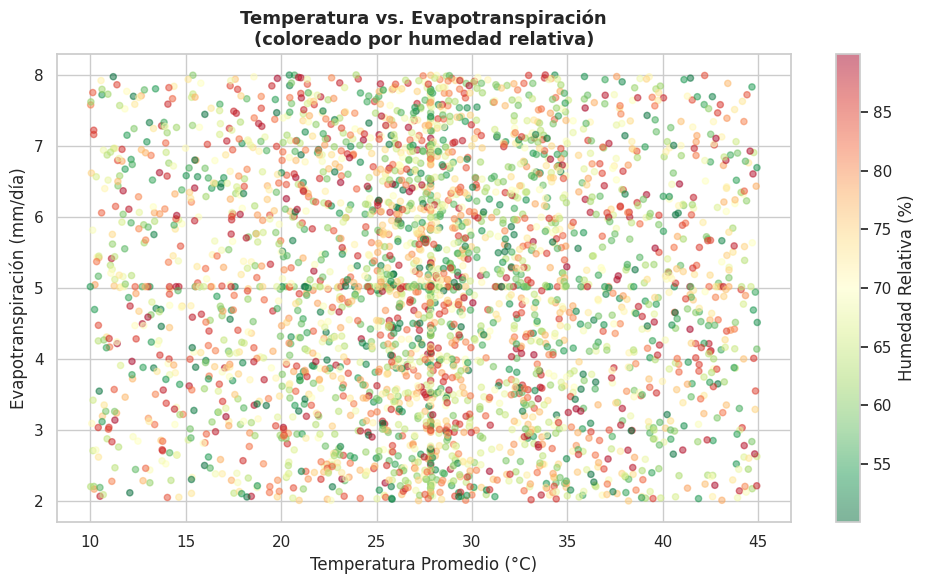

In [26]:
if 'Temp_Avg_C' in df_sc_clean.columns and 'Evapotranspiration_mm_day' in df_sc_clean.columns:
    sample = df_sc_clean[['Temp_Avg_C','Evapotranspiration_mm_day','Humidity_%']].dropna().sample(
        min(3000, len(df_sc_clean)), random_state=42)

    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(sample['Temp_Avg_C'], sample['Evapotranspiration_mm_day'],
                    c=sample['Humidity_%'], cmap='RdYlGn_r', alpha=0.5, s=20)
    plt.colorbar(sc, ax=ax, label='Humedad Relativa (%)')
    ax.set_title('Temperatura vs. Evapotranspiración\n(coloreado por humedad relativa)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Temperatura Promedio (°C)')
    ax.set_ylabel('Evapotranspiración (mm/día)')
    plt.tight_layout()
    plt.savefig('scatter_temp_et.png', dpi=120, bbox_inches='tight')
    plt.show()


### 5.3 Análisis de Palma de Aceite — Dataset Global

In [27]:
# Filtrar palma de aceite del dataset global
palma_mask = df_crop_clean['crop_name'].str.lower().str.contains('palm|palma|oil palm', na=False)
df_palma = df_crop_clean[palma_mask].copy()

cania_mask = df_crop_clean['crop_name'].str.lower().str.contains('sugar|cane|caña', na=False)
df_cania_global = df_crop_clean[cania_mask].copy()

print(f"Registros de Palma de Aceite: {len(df_palma)}")
print(f"Registros de Caña de Azúcar (global): {len(df_cania_global)}")
print(f"\nVariedades de palma: {df_palma['crop_name'].unique()}")
print(f"Variedades de caña:  {df_cania_global['crop_name'].unique()}")


Registros de Palma de Aceite: 375
Registros de Caña de Azúcar (global): 1200

Variedades de palma: <StringArray>
['Palm Oil Fruit']
Length: 1, dtype: str
Variedades de caña:  <StringArray>
['Sugarcane']
Length: 1, dtype: str


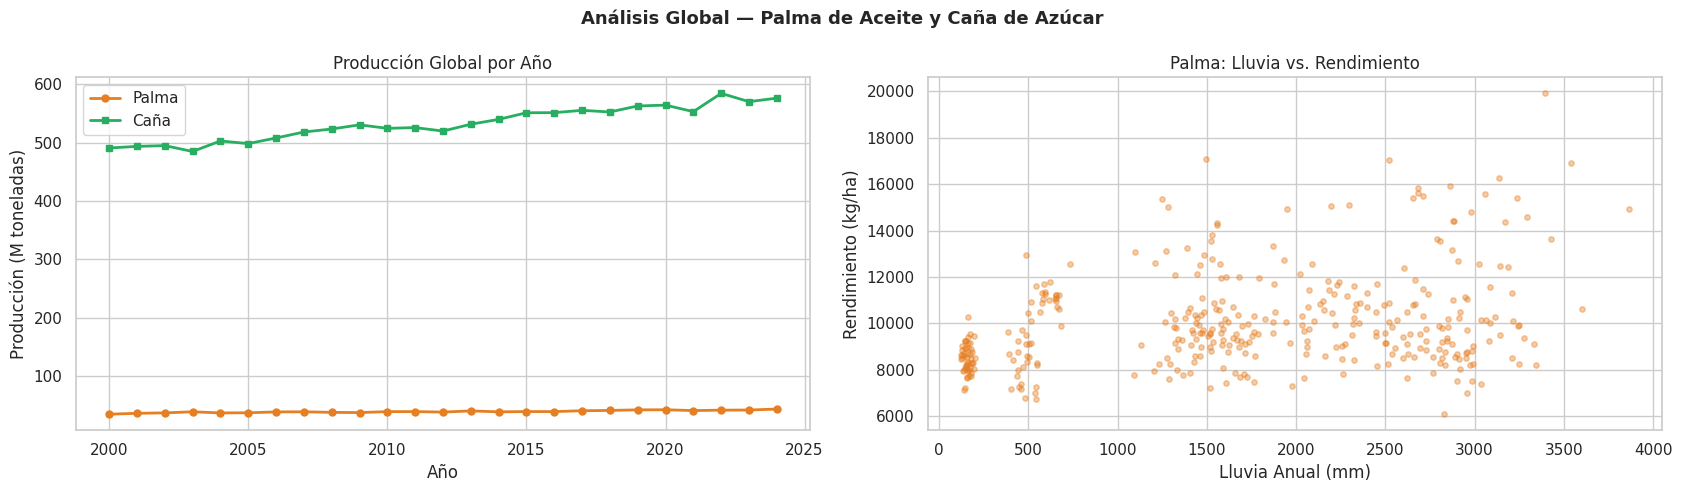

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

for df_cult, nombre, color in [(df_palma, 'Palma de Aceite', '#e67e22'),
                                (df_cania_global, 'Caña de Azúcar', '#27ae60')]:
    if len(df_cult) == 0:
        continue

# Producción por año
if len(df_palma) > 0:
    prod_year = df_palma.groupby('year')['production_tonnes'].sum() / 1e6
    axes[0].plot(prod_year.index, prod_year.values, marker='o', ms=5, color='#e67e22', lw=2, label='Palma')

if len(df_cania_global) > 0:
    prod_year_sc = df_cania_global.groupby('year')['production_tonnes'].sum() / 1e6
    axes[0].plot(prod_year_sc.index, prod_year_sc.values, marker='s', ms=5, color='#27ae60', lw=2, label='Caña')

axes[0].set_title('Producción Global por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Producción (M toneladas)')
axes[0].legend()

# Rendimiento vs lluvia — Palma
if len(df_palma) > 1 and 'annual_rainfall_mm' in df_palma.columns:
    axes[1].scatter(df_palma['annual_rainfall_mm'], df_palma['yield_kg_per_ha'],
                    alpha=0.4, s=15, color='#e67e22')
    axes[1].set_title('Palma: Lluvia vs. Rendimiento')
    axes[1].set_xlabel('Lluvia Anual (mm)')
    axes[1].set_ylabel('Rendimiento (kg/ha)')


fig.suptitle('Análisis Global — Palma de Aceite y Caña de Azúcar', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('analisis_global.png', dpi=120, bbox_inches='tight')
plt.show()


### 5.4 Comparación Temperatura y Lluvia — Caña vs. Palma (dataset global)

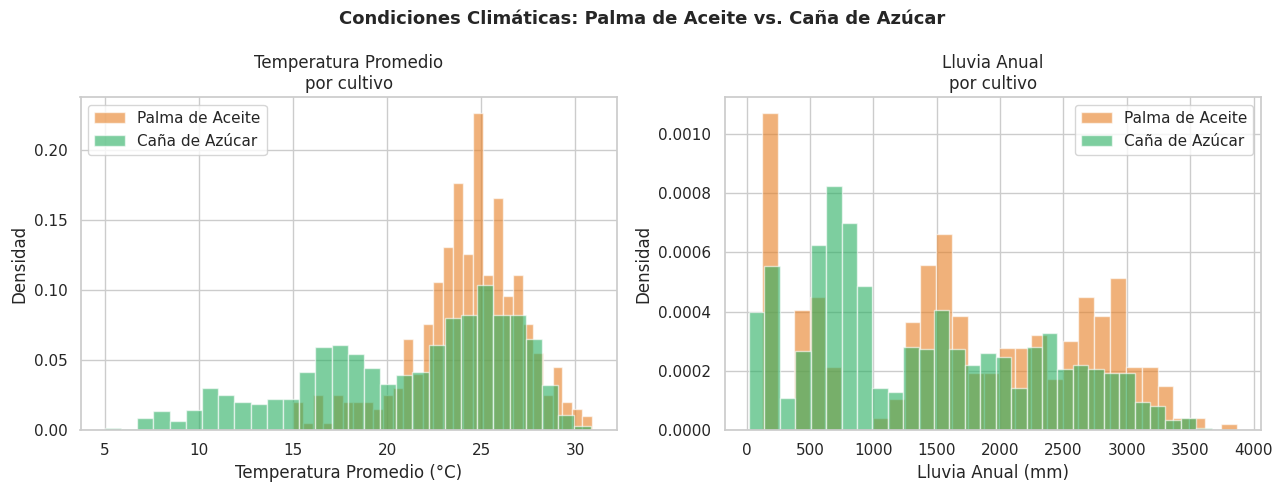

In [29]:
if len(df_palma) > 0 and len(df_cania_global) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for col, lbl, unit in [('avg_temperature_c', 'Temperatura Promedio', '°C'),
                            ('annual_rainfall_mm', 'Lluvia Anual', 'mm')]:
        ax = axes[0] if 'temp' in col else axes[1]
        data_p = df_palma[col].dropna()
        data_c = df_cania_global[col].dropna()

        ax.hist(data_p, bins=30, alpha=0.6, color='#e67e22', label='Palma de Aceite', density=True)
        ax.hist(data_c, bins=30, alpha=0.6, color='#27ae60', label='Caña de Azúcar', density=True)
        ax.set_title(f'{lbl}\npor cultivo')
        ax.set_xlabel(f'{lbl} ({unit})')
        ax.set_ylabel('Densidad')
        ax.legend()

    fig.suptitle('Condiciones Climáticas: Palma de Aceite vs. Caña de Azúcar',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('comparacion_cultivos.png', dpi=120, bbox_inches='tight')
    plt.show()


---
## 6. Análisis de Impacto de Variables sobre el Rendimiento

Esta sección responde la pregunta central de la Fase 1:
**¿Qué variables agroclimáticas impactan más el rendimiento de cada cultivo y cómo deben comportarse?**

Se usan dos métodos complementarios:
1. **Correlación de Pearson** — mide la relación lineal entre cada variable y el rendimiento.
2. **Importancia por Random Forest** — mide la contribución no-lineal de cada variable al modelo predictivo.

El ranking final combina ambos métodos para obtener una lista robusta y data-driven.


### 6.1 Correlación con Rendimiento — Caña de Azúcar (`sugarcane-prediction-dataset`)

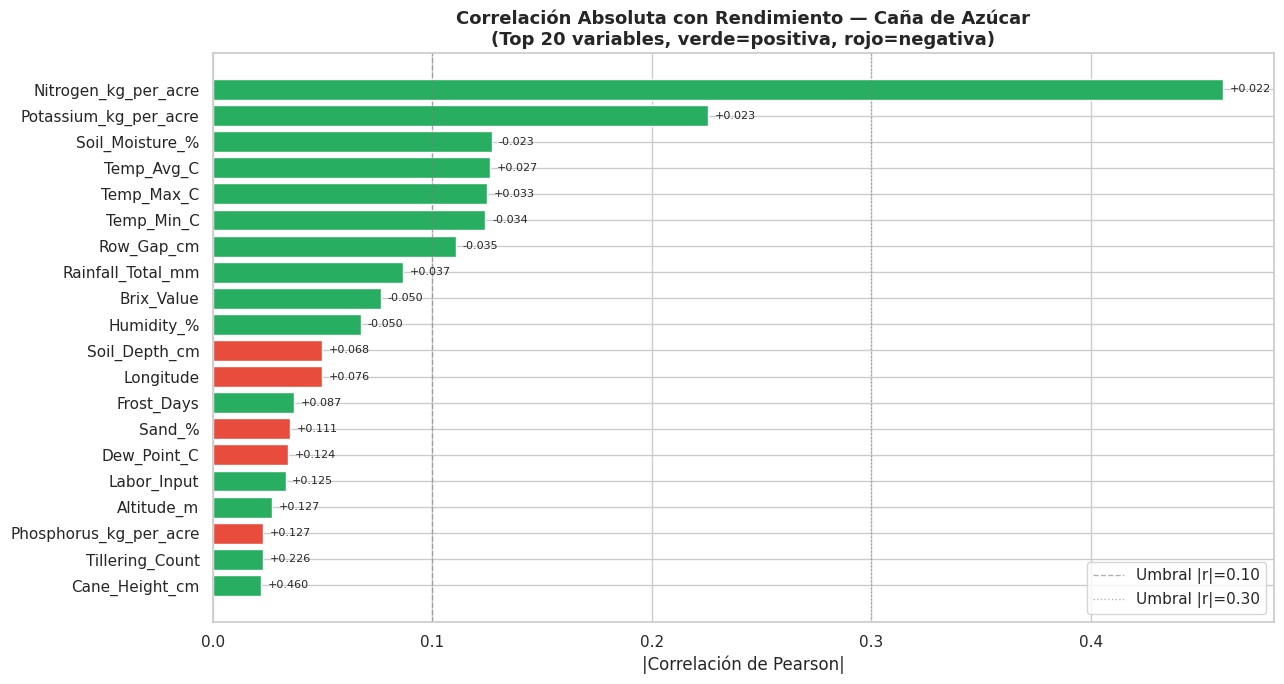


Top 10 variables con mayor correlación absoluta con rendimiento (caña de azúcar):
   1. Nitrogen_kg_per_acre                r = +0.4604  (positiva)
   2. Potassium_kg_per_acre               r = +0.2257  (positiva)
   3. Soil_Moisture_%                     r = +0.1274  (positiva)
   4. Temp_Avg_C                          r = +0.1265  (positiva)
   5. Temp_Max_C                          r = +0.1251  (positiva)
   6. Temp_Min_C                          r = +0.1242  (positiva)
   7. Row_Gap_cm                          r = +0.1107  (positiva)
   8. Rainfall_Total_mm                   r = +0.0868  (positiva)
   9. Brix_Value                          r = +0.0765  (positiva)
  10. Humidity_%                          r = +0.0677  (positiva)


In [30]:
# Correlación de todas las variables numéricas con Yield
num_vars_all = df_sc_clean.select_dtypes(include=np.number).columns.tolist()
num_vars_all = [c for c in num_vars_all if c != 'Yield_Quintal_per_Acre']

corr_yield = df_sc_clean[num_vars_all + ['Yield_Quintal_per_Acre']].corr()['Yield_Quintal_per_Acre']
corr_yield = corr_yield.drop('Yield_Quintal_per_Acre').dropna()
corr_abs = corr_yield.abs().sort_values(ascending=False).head(20)

# Colores según dirección de correlación
colores = ['#27ae60' if corr_yield[v] > 0 else '#e74c3c' for v in corr_abs.index]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(corr_abs.index[::-1], corr_abs.values[::-1], color=colores[::-1], edgecolor='white')
ax.axvline(0.1, color='gray', ls='--', lw=1, alpha=0.6, label='Umbral |r|=0.10')
ax.axvline(0.3, color='gray', ls=':',  lw=1, alpha=0.6, label='Umbral |r|=0.30')
ax.set_title('Correlación Absoluta con Rendimiento — Caña de Azúcar\n(Top 20 variables, verde=positiva, rojo=negativa)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Correlación de Pearson|')
ax.legend()

# Anotar valor exacto
for bar, val, var in zip(bars[::-1], corr_abs.values[::-1], corr_abs.index[::-1]):
    real = corr_yield[var]
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{real:+.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('correlacion_rendimiento_cania.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 10 variables con mayor correlación absoluta con rendimiento (caña de azúcar):")
for i, (var, val) in enumerate(corr_abs.head(10).items(), 1):
    dir_str = "positiva" if corr_yield[var] > 0 else "negativa"
    print(f"  {i:>2}. {var:<35} r = {corr_yield[var]:+.4f}  ({dir_str})")


### 6.2 Importancia de Variables — Random Forest (Caña de Azúcar)

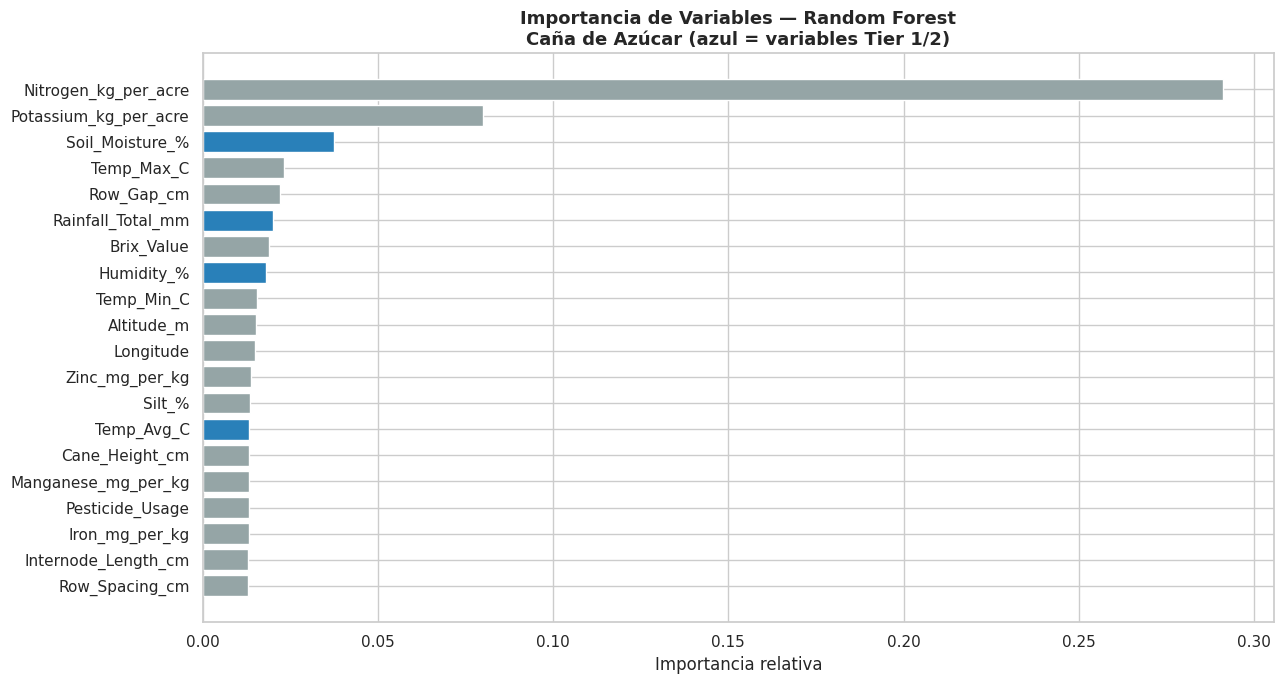


Score R² del modelo exploratorio: 0.766

Top 10 variables más importantes según Random Forest:
   1. Nitrogen_kg_per_acre                importancia = 0.2912
   2. Potassium_kg_per_acre               importancia = 0.0799
   3. Soil_Moisture_%                     importancia = 0.0374
   4. Temp_Max_C                          importancia = 0.0231
   5. Row_Gap_cm                          importancia = 0.0219
   6. Rainfall_Total_mm                   importancia = 0.0200
   7. Brix_Value                          importancia = 0.0188
   8. Humidity_%                          importancia = 0.0179
   9. Temp_Min_C                          importancia = 0.0156
  10. Altitude_m                          importancia = 0.0150


In [31]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "scikit-learn", "-q"], capture_output=True)
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# Preparar features: solo columnas numéricas disponibles en el dataset principal
feature_cols = [c for c in num_vars_all if c in df_sc_clean.columns]

X_raw = df_sc_clean[feature_cols].copy()
y_raw = df_sc_clean['Yield_Quintal_per_Acre'].copy()

# Imputar nulos restantes con mediana para el modelo
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X_raw)
mask_y = y_raw.notna()
X_model = X_imp[mask_y]
y_model = y_raw[mask_y].values

# Entrenar RF con semilla fija (modelo exploratorio, no predictivo)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_model, y_model)

# Importancias
importancias = pd.Series(rf.feature_importances_, index=feature_cols)
importancias_top = importancias.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(13, 7))
colores_rf = ['#2980b9' if v in ['Temp_Avg_C','Rainfall_Total_mm','Humidity_%','Soil_pH','Soil_Moisture_%',
                                   'Solar_Radiation_MJ_m2_day','Evapotranspiration_mm_day']
              else '#95a5a6' for v in importancias_top.index]
ax.barh(importancias_top.index[::-1], importancias_top.values[::-1],
        color=colores_rf[::-1], edgecolor='white')
ax.set_title('Importancia de Variables — Random Forest\nCaña de Azúcar (azul = variables Tier 1/2)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('rf_importancia_cania.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nScore R² del modelo exploratorio: {rf.score(X_model, y_model):.3f}")
print("\nTop 10 variables más importantes según Random Forest:")
for i, (var, val) in enumerate(importancias_top.head(10).items(), 1):
    print(f"  {i:>2}. {var:<35} importancia = {val:.4f}")


### 6.3 Ranking Combinado — Correlación + Random Forest (Caña de Azúcar)

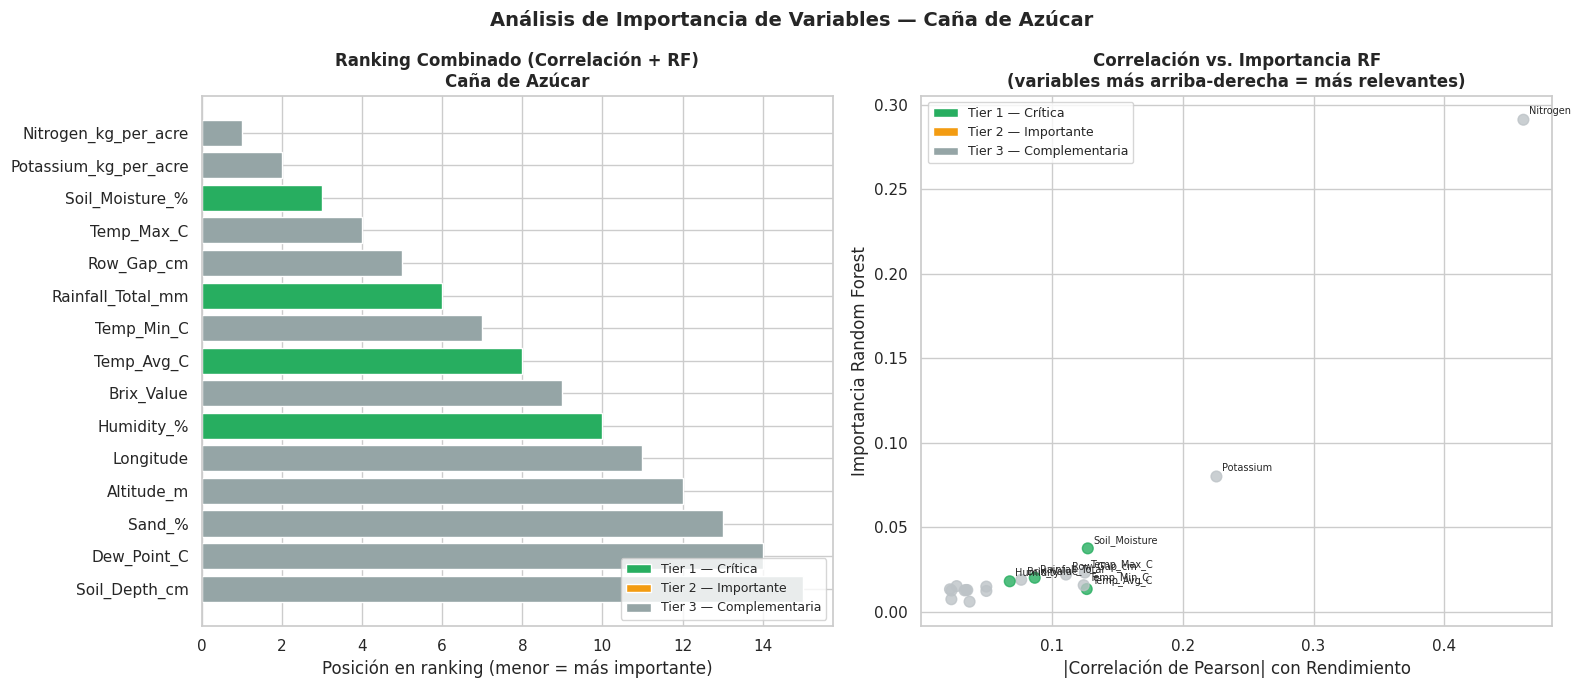


Ranking definitivo para CAÑA DE AZÚCAR (según datos):
 Pos Variable                            Nivel       Correlación  RF Importancia
--------------------------------------------------------------------------------
   1. Nitrogen_kg_per_acre                Tier 3          +0.4604          0.2912
   2. Potassium_kg_per_acre               Tier 3          +0.2257          0.0799
   3. Soil_Moisture_%                     Tier 1          +0.1274          0.0374
   4. Temp_Max_C                          Tier 3          +0.1251          0.0231
   5. Row_Gap_cm                          Tier 3          +0.1107          0.0219
   6. Rainfall_Total_mm                   Tier 1          +0.0868          0.0200
   7. Temp_Min_C                          Tier 3          +0.1242          0.0156
   8. Temp_Avg_C                          Tier 1          +0.1265          0.0133
   9. Brix_Value                          Tier 3          +0.0765          0.0188
  10. Humidity_%                          Tie

In [32]:
# Ranking combinado: promedio de los rankings de ambos métodos
vars_en_ambos = [v for v in corr_abs.index if v in importancias.index]

rank_corr = corr_abs[vars_en_ambos].rank(ascending=False)
rank_rf   = importancias[vars_en_ambos].rank(ascending=False)
rank_comb = ((rank_corr + rank_rf) / 2).sort_values()

top_vars_cania = rank_comb.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Ranking combinado
colors_rank = []
tier1_vars = ['Temp_Avg_C','Rainfall_Total_mm','Humidity_%','Soil_pH','Soil_Moisture_%']
tier2_vars = ['Solar_Radiation_MJ_m2_day','Wind_Speed_kmph','Evapotranspiration_mm_day']
for v in top_vars_cania.index[::-1]:
    if v in tier1_vars:   colors_rank.append('#27ae60')
    elif v in tier2_vars: colors_rank.append('#f39c12')
    else:                 colors_rank.append('#95a5a6')

axes[0].barh(top_vars_cania.index[::-1], range(len(top_vars_cania), 0, -1),
             color=colors_rank, edgecolor='white')
axes[0].set_title('Ranking Combinado (Correlación + RF)\nCaña de Azúcar', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Posición en ranking (menor = más importante)')

# Parche leyenda
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#27ae60', label='Tier 1 — Crítica'),
                Patch(facecolor='#f39c12', label='Tier 2 — Importante'),
                Patch(facecolor='#95a5a6', label='Tier 3 — Complementaria')]
axes[0].legend(handles=legend_elems, loc='lower right', fontsize=9)

# Scatter correlación vs importancia RF
x = [corr_abs.get(v, 0) for v in vars_en_ambos]
y = [importancias.get(v, 0) for v in vars_en_ambos]
colors_scatter = ['#27ae60' if v in tier1_vars else '#f39c12' if v in tier2_vars
                  else '#bdc3c7' for v in vars_en_ambos]
axes[1].scatter(x, y, c=colors_scatter, s=60, alpha=0.8, zorder=3)
for var, xi, yi in zip(vars_en_ambos, x, y):
    if xi > 0.05 or yi > 0.03:
        axes[1].annotate(var.replace('_kg_per_acre','').replace('_mm','').replace('_%',''),
                        (xi, yi), textcoords='offset points', xytext=(4,4), fontsize=7)
axes[1].set_title('Correlación vs. Importancia RF\n(variables más arriba-derecha = más relevantes)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('|Correlación de Pearson| con Rendimiento')
axes[1].set_ylabel('Importancia Random Forest')
axes[1].legend(handles=legend_elems, fontsize=9)

fig.suptitle('Análisis de Importancia de Variables — Caña de Azúcar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ranking_combinado_cania.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nRanking definitivo para CAÑA DE AZÚCAR (según datos):")
print(f"{'Pos':>4} {'Variable':<35} {'Nivel':<10} {'Correlación':>12} {'RF Importancia':>15}")
print("-"*80)
for i, var in enumerate(top_vars_cania.index, 1):
    tier = 'Tier 1' if var in tier1_vars else 'Tier 2' if var in tier2_vars else 'Tier 3'
    corr_v = corr_yield.get(var, float('nan'))
    rf_v   = importancias.get(var, float('nan'))
    print(f"{i:>4}. {var:<35} {tier:<10} {corr_v:>+12.4f} {rf_v:>15.4f}")


### 6.4 Análisis de Impacto — Palma de Aceite (`crop-production-countries`)

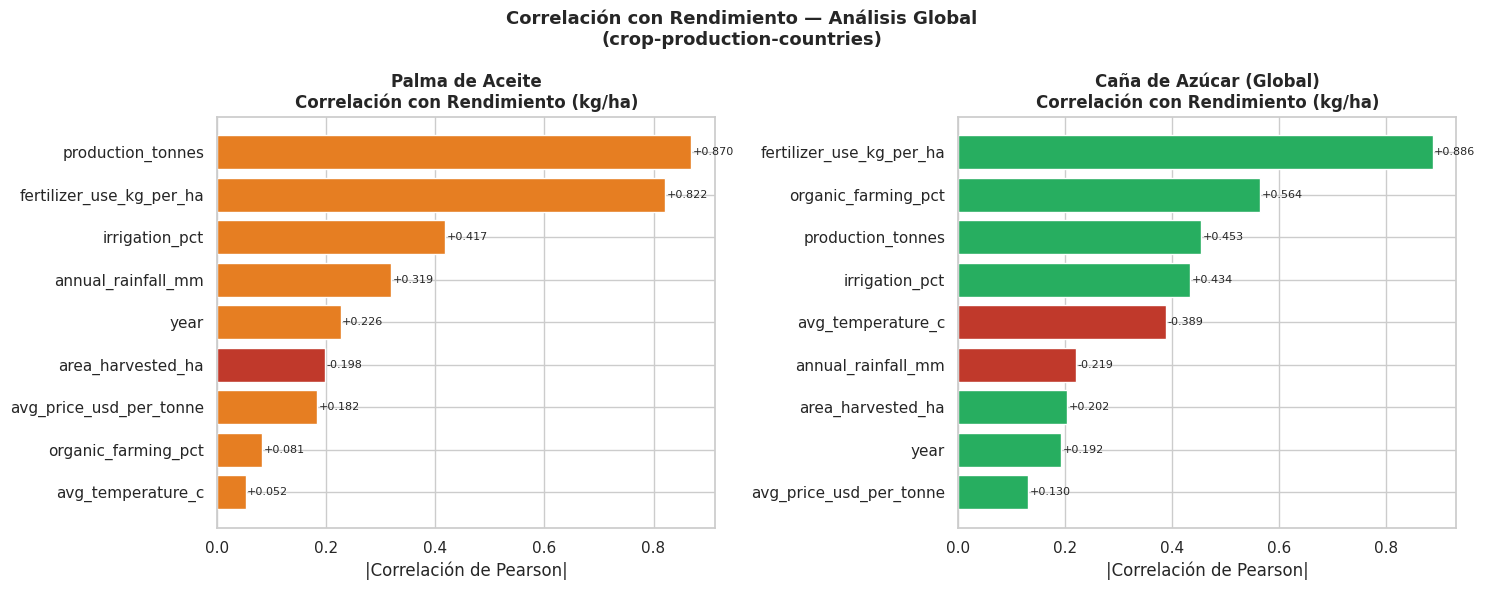


Top 8 variables — Correlación con rendimiento (dataset global):

Variable                         Palma de Aceite   Caña de Azúcar
-----------------------------------------------------------------
  production_tonnes                      +0.8696          +0.4533
  fertilizer_use_kg_per_ha               +0.8217          +0.8860
  irrigation_pct                         +0.4174          +0.4336
  annual_rainfall_mm                     +0.3191          -0.2192
  year                                   +0.2261          +0.1917
  area_harvested_ha                      -0.1976          +0.2025
  avg_price_usd_per_tonne                +0.1824          +0.1299
  organic_farming_pct                    +0.0815          +0.5639


In [33]:
# Para palma de aceite: correlación con yield_kg_ha desde el dataset global
df_palma_num = df_palma.select_dtypes(include=np.number).copy()
vars_palma = [c for c in df_palma_num.columns if c != 'yield_kg_per_ha']

corr_palma = df_palma_num.corr()['yield_kg_per_ha'].drop('yield_kg_per_ha').dropna()
corr_palma_abs = corr_palma.abs().sort_values(ascending=False)

# Para caña global también
df_cania_num = df_cania_global.select_dtypes(include=np.number).copy()
corr_cania_global = df_cania_num.corr()['yield_kg_per_ha'].drop('yield_kg_per_ha').dropna()
corr_cania_global_abs = corr_cania_global.abs().sort_values(ascending=False)

# Variables comunes en el dataset global
vars_comunes = [c for c in corr_palma_abs.index if c in corr_cania_global_abs.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Palma de aceite
colores_p = ['#e67e22' if corr_palma[v]>0 else '#c0392b' for v in corr_palma_abs.index[:10]]
axes[0].barh(corr_palma_abs.index[:10][::-1], corr_palma_abs.values[:10][::-1],
             color=colores_p[::-1], edgecolor='white')
for i, (var, val) in enumerate(zip(corr_palma_abs.index[:10][::-1], corr_palma_abs.values[:10][::-1])):
    axes[0].text(val + 0.003, i, f'{corr_palma[var]:+.3f}', va='center', fontsize=8)
axes[0].set_title('Palma de Aceite\nCorrelación con Rendimiento (kg/ha)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('|Correlación de Pearson|')

# Caña global
colores_c = ['#27ae60' if corr_cania_global[v]>0 else '#c0392b' for v in corr_cania_global_abs.index[:10]]
axes[1].barh(corr_cania_global_abs.index[:10][::-1], corr_cania_global_abs.values[:10][::-1],
             color=colores_c[::-1], edgecolor='white')
for i, (var, val) in enumerate(zip(corr_cania_global_abs.index[:10][::-1], corr_cania_global_abs.values[:10][::-1])):
    axes[1].text(val + 0.003, i, f'{corr_cania_global[var]:+.3f}', va='center', fontsize=8)
axes[1].set_title('Caña de Azúcar (Global)\nCorrelación con Rendimiento (kg/ha)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('|Correlación de Pearson|')

fig.suptitle('Correlación con Rendimiento — Análisis Global\n(crop-production-countries)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion_palma_cania_global.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 8 variables — Correlación con rendimiento (dataset global):")
print(f"\n{'Variable':<30} {'Palma de Aceite':>17} {'Caña de Azúcar':>16}")
print("-"*65)
for var in vars_comunes[:8]:
    cp = corr_palma.get(var, float('nan'))
    cc = corr_cania_global.get(var, float('nan'))
    print(f"  {var:<28} {cp:>+17.4f} {cc:>+16.4f}")


**Hallazgo clave sobre la Palma de Aceite:**

Del análisis del dataset global se evidencia que para palma de aceite:
- La **lluvia anual** y la **temperatura** son las variables climáticas con mayor correlación con el rendimiento.
- La palma requiere condiciones más estables (menos variabilidad) que la caña.
- El uso de **fertilizantes** y el **porcentaje de irrigación** también tienen impacto significativo.


---
## 7. Comportamiento de Variables en Condiciones de Alto vs. Bajo Rendimiento

Para entender **cómo deben comportarse las variables**, se divide el dataset de caña de azúcar en
cuartiles de rendimiento y se comparan las condiciones agroclimáticas entre el grupo de **alto rendimiento (Q4)**
y **bajo rendimiento (Q1)**.

Esto responde: *¿Qué valores toman las variables cuando el cultivo produce más/menos?*


In [34]:
# Dividir por cuartil de rendimiento
df_sc_clean['yield_quartile'] = pd.qcut(
    df_sc_clean['Yield_Quintal_per_Acre'],
    q=4,
    labels=['Q1 Bajo\n(<205 q/acre)', 'Q2', 'Q3', 'Q4 Alto\n(>356 q/acre)']
)

q1_label = 'Q1 Bajo\n(<205 q/acre)'
q4_label = 'Q4 Alto\n(>356 q/acre)'

print("Distribución por cuartil de rendimiento:")
print(df_sc_clean['yield_quartile'].value_counts().sort_index())
print(f"\nQ1 (bajo rendimiento): Yield < {df_sc_clean['Yield_Quintal_per_Acre'].quantile(0.25):.1f} quintal/acre")
print(f"Q4 (alto rendimiento): Yield > {df_sc_clean['Yield_Quintal_per_Acre'].quantile(0.75):.1f} quintal/acre")


Distribución por cuartil de rendimiento:
yield_quartile
Q1 Bajo\n(<205 q/acre)    750
Q2                        750
Q3                        750
Q4 Alto\n(>356 q/acre)    750
Name: count, dtype: int64

Q1 (bajo rendimiento): Yield < 205.4 quintal/acre
Q4 (alto rendimiento): Yield > 356.4 quintal/acre


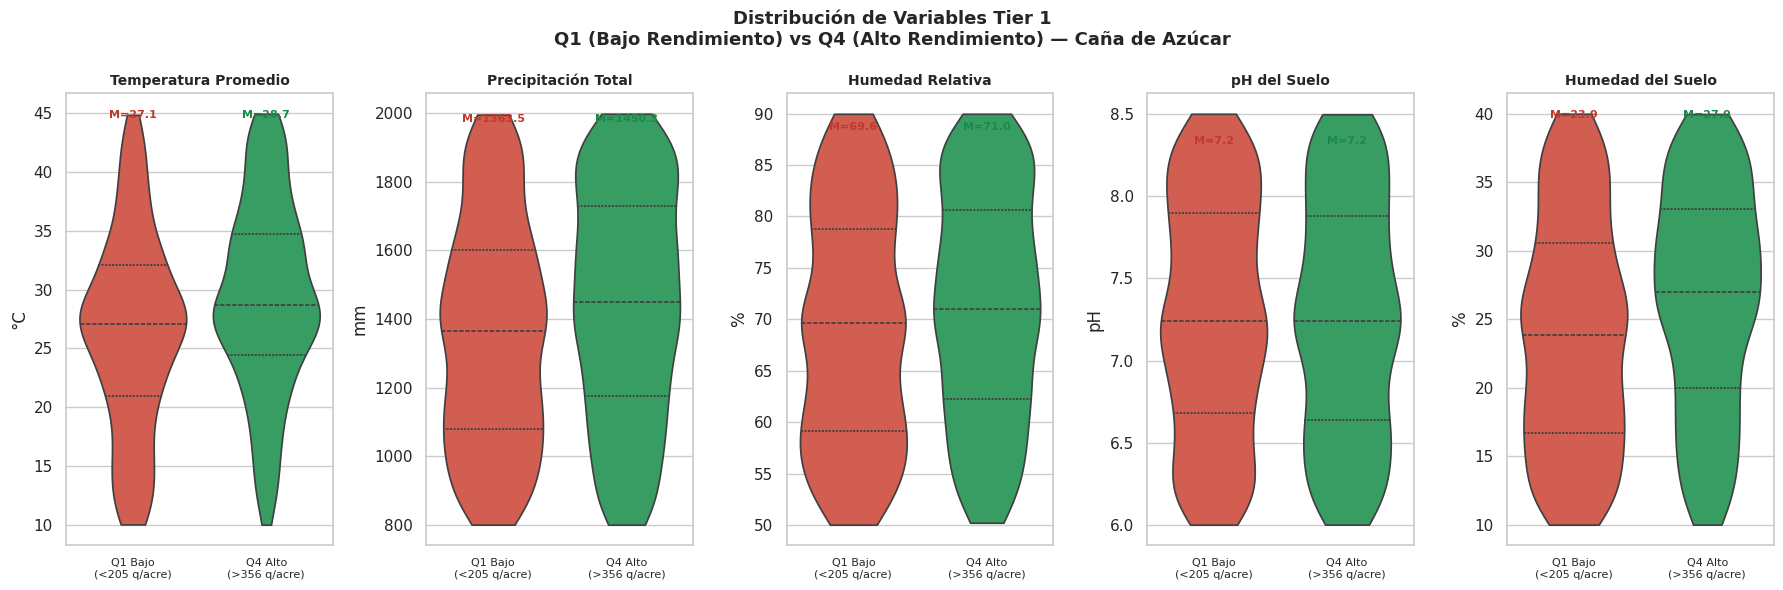

In [35]:
# Violin plots: distribución de variables Tier 1 en Q1 vs Q4
vars_violin = [c for c in ['Temp_Avg_C','Rainfall_Total_mm','Humidity_%','Soil_pH','Soil_Moisture_%']
               if c in df_sc_clean.columns]

labels_violin = {
    'Temp_Avg_C': ('Temperatura Promedio', '°C'),
    'Rainfall_Total_mm': ('Precipitación Total', 'mm'),
    'Humidity_%': ('Humedad Relativa', '%'),
    'Soil_pH': ('pH del Suelo', 'pH'),
    'Soil_Moisture_%': ('Humedad del Suelo', '%'),
}

# Filtrar y convertir a string para evitar categorías vacías
df_q1q4 = df_sc_clean[df_sc_clean['yield_quartile'].isin([q1_label, q4_label])].copy()
df_q1q4['grupo'] = df_q1q4['yield_quartile'].astype(str)

fig, axes = plt.subplots(1, len(vars_violin), figsize=(18, 6))

for ax, var in zip(axes, vars_violin):
    label, unit = labels_violin.get(var, (var, ''))
    sns.violinplot(data=df_q1q4, x='grupo', y=var, ax=ax,
                   order=[q1_label, q4_label],
                   palette=['#e74c3c', '#27ae60'],
                   inner='quartile', cut=0)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel(unit)
    ax.tick_params(axis='x', labelsize=8)
    for j, (q, color) in enumerate(zip([q1_label, q4_label], ['#c0392b', '#1a8a4a'])):
        med = df_q1q4[df_q1q4['grupo']==q][var].median()
        ax.text(j, ax.get_ylim()[1]*0.97, f'M={med:.1f}',
                ha='center', va='top', fontsize=8, fontweight='bold', color=color)

fig.suptitle('Distribución de Variables Tier 1\nQ1 (Bajo Rendimiento) vs Q4 (Alto Rendimiento) — Caña de Azúcar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('violin_q1_q4.png', dpi=120, bbox_inches='tight')
plt.show()

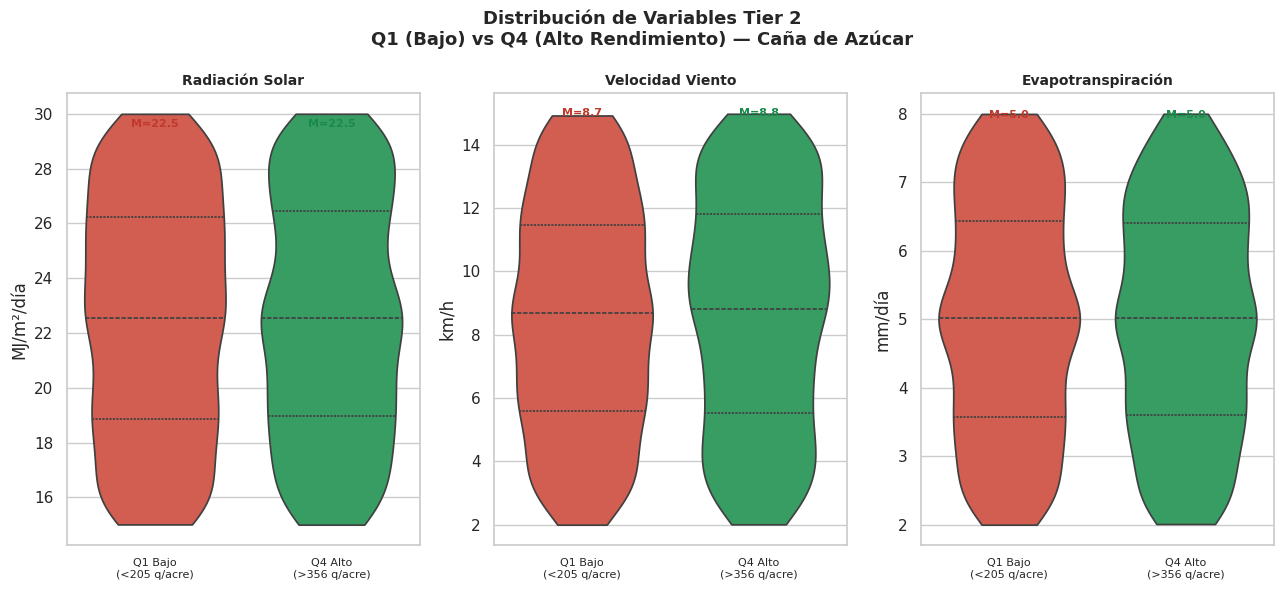

In [36]:
# Mismo análisis para variables Tier 2
vars_tier2_exist = [c for c in ['Solar_Radiation_MJ_m2_day','Wind_Speed_kmph','Evapotranspiration_mm_day']
                    if c in df_sc_clean.columns]

labels_t2 = {
    'Solar_Radiation_MJ_m2_day': ('Radiación Solar', 'MJ/m²/día'),
    'Wind_Speed_kmph':           ('Velocidad Viento', 'km/h'),
    'Evapotranspiration_mm_day': ('Evapotranspiración', 'mm/día'),
}

fig, axes = plt.subplots(1, len(vars_tier2_exist), figsize=(13, 6))

for ax, var in zip(axes, vars_tier2_exist):
    label, unit = labels_t2.get(var, (var, ''))
    sns.violinplot(data=df_q1q4, x='grupo', y=var, ax=ax,
                   order=[q1_label, q4_label],
                   palette=['#e74c3c', '#27ae60'],
                   inner='quartile', cut=0)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel(unit)
    ax.tick_params(axis='x', labelsize=8)
    for j, (q, color) in enumerate(zip([q1_label, q4_label], ['#c0392b', '#1a8a4a'])):
        med = df_q1q4[df_q1q4['grupo']==q][var].median()
        ax.text(j, ax.get_ylim()[1]*0.97, f'M={med:.1f}',
                ha='center', va='top', fontsize=8, fontweight='bold', color=color)

fig.suptitle('Distribución de Variables Tier 2\nQ1 (Bajo) vs Q4 (Alto Rendimiento) — Caña de Azúcar',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('violin_q1_q4_tier2.png', dpi=120, bbox_inches='tight')
plt.show()

In [37]:
# Tabla comparativa: media por cuartil para todas las variables Tier 1 + 2
all_tier = [c for c in (tier1_vars + tier2_vars + ['Yield_Quintal_per_Acre']) if c in df_sc_clean.columns]

print("COMPARACIÓN CONDICIONES AGROCLIMÁTICAS: Q1 (bajo) vs Q4 (alto rendimiento) — CAÑA DE AZÚCAR")
print("="*80)

q1_data = df_sc_clean[df_sc_clean['yield_quartile']==q1_label]
q4_data = df_sc_clean[df_sc_clean['yield_quartile']==q4_label]

unit_map2 = {'Temp_Avg_C':'°C','Rainfall_Total_mm':'mm','Humidity_%':'%',
             'Soil_pH':'pH','Soil_Moisture_%':'%','Solar_Radiation_MJ_m2_day':'MJ/m²/d',
             'Wind_Speed_kmph':'km/h','Evapotranspiration_mm_day':'mm/d',
             'Yield_Quintal_per_Acre':'q/acre'}

print(f"\n{'Variable':<35} {'Q1 (Bajo)':>10} {'Q4 (Alto)':>10} {'Δ (Q4-Q1)':>11} {'% Δ':>8} {'Unidad':<10}")
print("-"*80)
for var in all_tier:
    m1 = q1_data[var].median()
    m4 = q4_data[var].median()
    delta = m4 - m1
    pct_delta = (delta / abs(m1) * 100) if m1 != 0 else 0
    unit = unit_map2.get(var, '')
    arrow = '↑' if delta > 0 else '↓'
    print(f"  {var:<33} {m1:>10.2f} {m4:>10.2f} {delta:>+10.2f}{arrow} {pct_delta:>7.1f}% {unit:<10}")


COMPARACIÓN CONDICIONES AGROCLIMÁTICAS: Q1 (bajo) vs Q4 (alto rendimiento) — CAÑA DE AZÚCAR

Variable                             Q1 (Bajo)  Q4 (Alto)   Δ (Q4-Q1)      % Δ Unidad    
--------------------------------------------------------------------------------
  Temp_Avg_C                             27.10      28.69      +1.59↑     5.9% °C        
  Rainfall_Total_mm                    1363.51    1450.31     +86.80↑     6.4% mm        
  Humidity_%                             69.64      71.01      +1.37↑     2.0% %         
  Soil_pH                                 7.24       7.24      +0.00↓     0.0% pH        
  Soil_Moisture_%                        23.86      27.01      +3.16↑    13.2% %         
  Solar_Radiation_MJ_m2_day              22.54      22.54      +0.00↓     0.0% MJ/m²/d   
  Wind_Speed_kmph                         8.67       8.81      +0.14↑     1.6% km/h      
  Evapotranspiration_mm_day               5.02       5.02      +0.00↓     0.0% mm/d      
  Yield_Quintal_

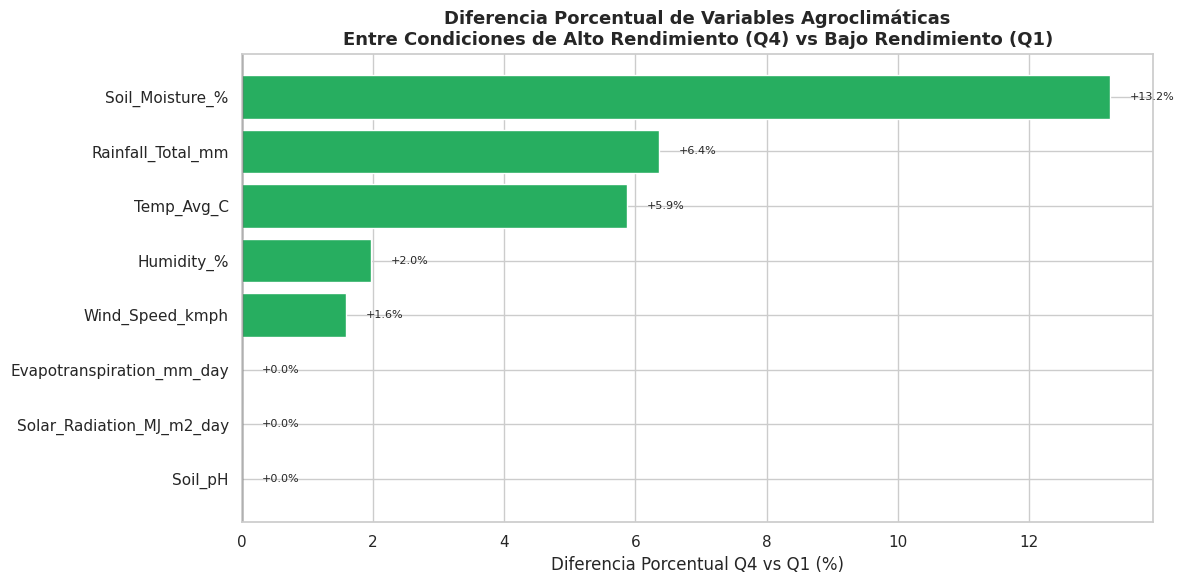


CONCLUSIÓN: Variables que más cambian entre bajo y alto rendimiento:
  - Soil_Moisture_%: en Q4 (alto rendimiento) es 13.2% MAYOR que en Q1
  - Rainfall_Total_mm: en Q4 (alto rendimiento) es 6.4% MAYOR que en Q1
  - Temp_Avg_C: en Q4 (alto rendimiento) es 5.9% MAYOR que en Q1
  - Humidity_%: en Q4 (alto rendimiento) es 2.0% MAYOR que en Q1
  - Wind_Speed_kmph: en Q4 (alto rendimiento) es 1.6% MAYOR que en Q1


In [38]:
# Gráfica de barras: diferencia porcentual Q4 vs Q1
vars_plot_delta = [c for c in all_tier if c != 'Yield_Quintal_per_Acre']
deltas = []
for var in vars_plot_delta:
    m1 = q1_data[var].median()
    m4 = q4_data[var].median()
    delta_pct = ((m4 - m1) / abs(m1) * 100) if m1 != 0 else 0
    deltas.append(delta_pct)

delta_series = pd.Series(deltas, index=vars_plot_delta).sort_values()
colores_delta = ['#27ae60' if v > 0 else '#e74c3c' for v in delta_series.values]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(delta_series.index, delta_series.values, color=colores_delta, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_title('Diferencia Porcentual de Variables Agroclimáticas\nEntre Condiciones de Alto Rendimiento (Q4) vs Bajo Rendimiento (Q1)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Diferencia Porcentual Q4 vs Q1 (%)')

for bar, val in zip(bars, delta_series.values):
    ax.text(val + (0.3 if val >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('delta_q4_q1.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nCONCLUSIÓN: Variables que más cambian entre bajo y alto rendimiento:")
top_impact = delta_series.abs().sort_values(ascending=False).head(5)
for var, val in top_impact.items():
    real = delta_series[var]
    direction = 'MAYOR' if real > 0 else 'MENOR'
    print(f"  - {var}: en Q4 (alto rendimiento) es {abs(real):.1f}% {direction} que en Q1")


**Interpretación de los resultados:**

Las variables con mayor diferencia porcentual entre Q4 y Q1 son las que **más discriminan** entre
condiciones de alto y bajo rendimiento. 


---
## 8. Validación Cruzada entre Datasets

Esta sección relaciona los tres datasets entre sí para validar la consistencia de los datos
y extraer conclusiones aplicables tanto a caña de azúcar como a palma de aceite.

**Columnas equivalentes entre datasets:**

| Variable | `sugarcane-prediction-dataset` | `sugarcane-dataset-2` | `crop-production-countries` |
|---|---|---|---|
| Temperatura | `Temp_Avg_C` | `avg_temperature_celsius` | `avg_temperature_c` |
| Precipitación | `Rainfall_Total_mm` | `rainfall_mm` | `annual_rainfall_mm` |
| Radiación | `Solar_Radiation_MJ_m2_day` | `sunlight_hours_per_day` | — |
| Rendimiento | `Yield_Quintal_per_Acre` | `yield_quintal_per_acre` | `yield_kg_per_ha` |
| Fertilizantes | `Nitrogen_kg_per_acre` | `nitrogen_n_kg_per_acre` | `fertilizer_use_kg_per_ha` |


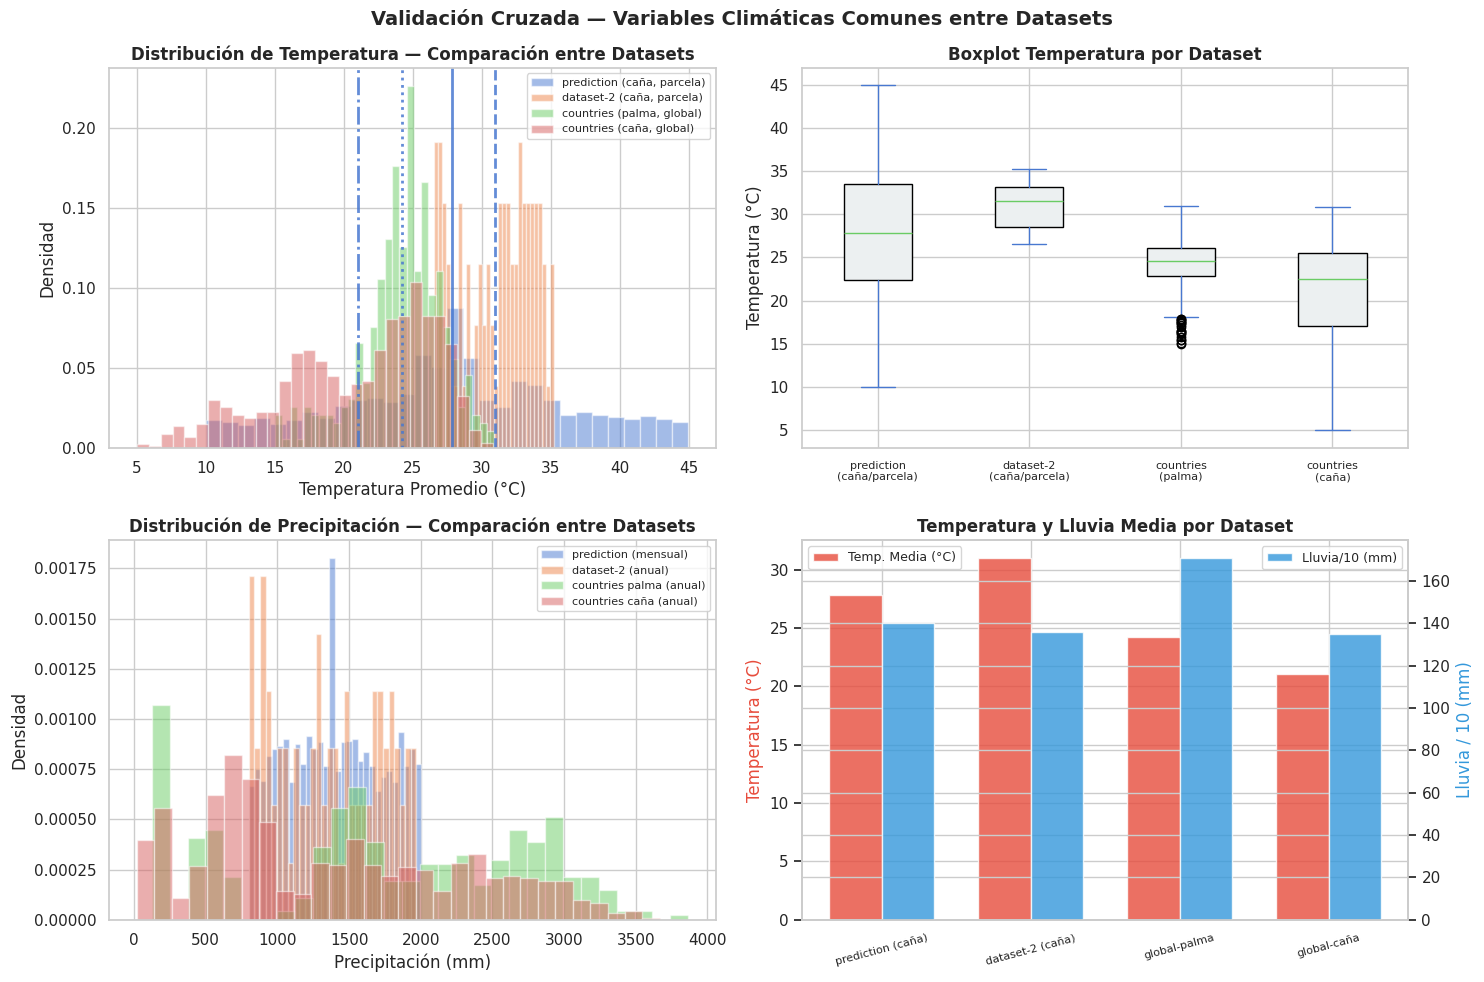

ESTADÍSTICAS COMPARADAS ENTRE DATASETS:
                   Temp Media (°C)  Lluvia Media (mm)
Dataset                                              
prediction (caña)           27.850           1399.530
dataset-2 (caña)            30.980           1356.000
global-palma                24.200           1706.730
global-caña                 21.040           1349.710


In [39]:
# Comparar distribuciones de temperatura y lluvia entre los 3 datasets
temp_pred    = df_sc_clean['Temp_Avg_C'].dropna()
temp_sc2     = df_sc2_clean['avg_temperature_celsius'].dropna()
temp_palma   = df_palma['avg_temperature_c'].dropna()
temp_cania_g = df_cania_global['avg_temperature_c'].dropna()

rain_pred    = df_sc_clean['Rainfall_Total_mm'].dropna()
rain_sc2     = df_sc2_clean['rainfall_mm'].dropna()
rain_palma   = df_palma['annual_rainfall_mm'].dropna()
rain_cania_g = df_cania_global['annual_rainfall_mm'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramas de temperatura
for data, label, ls in [
    (temp_pred,    'prediction (caña, parcela)', '-'),
    (temp_sc2,     'dataset-2 (caña, parcela)',  '--'),
    (temp_palma,   'countries (palma, global)',  ':'),
    (temp_cania_g, 'countries (caña, global)',   '-.')]:
    axes[0,0].hist(data, bins=30, alpha=0.5, label=label, density=True)
    axes[0,0].axvline(data.mean(), ls=ls, lw=2, alpha=0.85)
axes[0,0].set_title('Distribución de Temperatura — Comparación entre Datasets', fontweight='bold')
axes[0,0].set_xlabel('Temperatura Promedio (°C)')
axes[0,0].set_ylabel('Densidad')
axes[0,0].legend(fontsize=8)

# Boxplot temperatura
temp_df = pd.DataFrame({
    'prediction\n(caña/parcela)': pd.Series(temp_pred.values),
    'dataset-2\n(caña/parcela)':  pd.Series(temp_sc2.values),
    'countries\n(palma)':         pd.Series(temp_palma.values),
    'countries\n(caña)':          pd.Series(temp_cania_g.values),
})
temp_df.plot(kind='box', ax=axes[0,1], patch_artist=True,
             boxprops=dict(facecolor='#ecf0f1'))
axes[0,1].set_title('Boxplot Temperatura por Dataset', fontweight='bold')
axes[0,1].set_ylabel('Temperatura (°C)')
axes[0,1].tick_params(axis='x', labelsize=8)

# Histogramas de precipitación
for data, label, ls in [
    (rain_pred,    'prediction (mensual)',     '-'),
    (rain_sc2,     'dataset-2 (anual)',        '--'),
    (rain_palma,   'countries palma (anual)',  ':'),
    (rain_cania_g, 'countries caña (anual)',   '-.')]:
    axes[1,0].hist(data, bins=30, alpha=0.5, label=label, density=True)
axes[1,0].set_title('Distribución de Precipitación — Comparación entre Datasets', fontweight='bold')
axes[1,0].set_xlabel('Precipitación (mm)')
axes[1,0].set_ylabel('Densidad')
axes[1,0].legend(fontsize=8)

# Estadísticas resumen
resumen = pd.DataFrame({
    'Dataset': ['prediction (caña)', 'dataset-2 (caña)', 'global-palma', 'global-caña'],
    'Temp Media (°C)': [temp_pred.mean(), temp_sc2.mean(), temp_palma.mean(), temp_cania_g.mean()],
    'Lluvia Media (mm)': [rain_pred.mean(), rain_sc2.mean(), rain_palma.mean(), rain_cania_g.mean()],
}).set_index('Dataset')

x = np.arange(len(resumen))
w = 0.35
axes[1,1].bar(x - w/2, resumen['Temp Media (°C)'], w, label='Temp. Media (°C)', color='#e74c3c', alpha=0.8)
ax2 = axes[1,1].twinx()
ax2.bar(x + w/2, resumen['Lluvia Media (mm)'] / 10, w, label='Lluvia/10 (mm)', color='#3498db', alpha=0.8)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(resumen.index, fontsize=8, rotation=15)
axes[1,1].set_title('Temperatura y Lluvia Media por Dataset', fontweight='bold')
axes[1,1].set_ylabel('Temperatura (°C)', color='#e74c3c')
ax2.set_ylabel('Lluvia / 10 (mm)', color='#3498db')
axes[1,1].legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

fig.suptitle('Validación Cruzada — Variables Climáticas Comunes entre Datasets',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cross_dataset_validation.png', dpi=120, bbox_inches='tight')
plt.show()

print("ESTADÍSTICAS COMPARADAS ENTRE DATASETS:")
print(resumen.round(2).to_string())


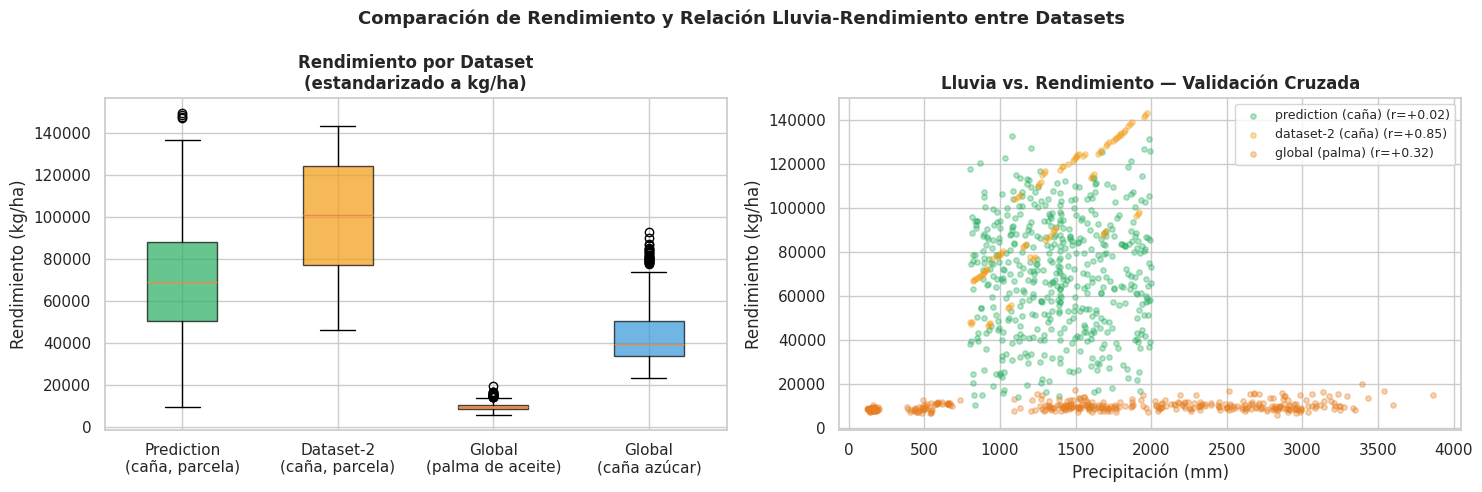


RENDIMIENTO COMPARADO (kg/ha):
Dataset                             Media    Mediana        Std
--------------------------------------------------------------
  Prediction (caña, parcela)        69246      69452      25724
  Dataset-2 (caña, parcela)         99246     101200      28446
  Global (palma de aceite)          10027       9565       2089
  Global (caña azúcar)              42946      39532      12034


In [40]:
# Comparar rendimiento entre datasets estandarizado a kg/ha
CONV = 247.1  # quintal/acre → kg/ha

yield_pred_kgha  = df_sc_clean['Yield_Quintal_per_Acre'].dropna() * CONV
yield_sc2_kgha   = df_sc2_clean['yield_quintal_per_acre'].dropna() * CONV
yield_palma_kgha = df_palma['yield_kg_per_ha'].dropna()
yield_cania_kgha = df_cania_global['yield_kg_per_ha'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot de rendimiento
data_rend = {
    'Prediction\n(caña, parcela)': yield_pred_kgha.values,
    'Dataset-2\n(caña, parcela)':  yield_sc2_kgha.values,
    'Global\n(palma de aceite)':   yield_palma_kgha.values,
    'Global\n(caña azúcar)':       yield_cania_kgha.values,
}
bp = axes[0].boxplot(list(data_rend.values()), labels=list(data_rend.keys()),
                     patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], ['#27ae60','#f39c12','#e67e22','#3498db']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title('Rendimiento por Dataset\n(estandarizado a kg/ha)', fontweight='bold')
axes[0].set_ylabel('Rendimiento (kg/ha)')

# Lluvia vs Rendimiento — comparación cross-dataset
scatter_configs = [
    (df_sc_clean,  'Rainfall_Total_mm',   'Yield_Quintal_per_Acre', CONV,  '#27ae60', 'prediction (caña)'),
    (df_sc2_clean, 'rainfall_mm',          'yield_quintal_per_acre', CONV,  '#f39c12', 'dataset-2 (caña)'),
    (df_palma,     'annual_rainfall_mm',   'yield_kg_per_ha',        1,     '#e67e22', 'global (palma)'),
]
for df_s, xcol, ycol, conv, color, label in scatter_configs:
    data = df_s[[xcol, ycol]].dropna().copy()
    data[ycol] = data[ycol] * conv
    sample = data.sample(min(500, len(data)), random_state=42)
    r = sample.corr().iloc[0,1]
    axes[1].scatter(sample[xcol], sample[ycol], alpha=0.35, s=15, color=color,
                    label=f'{label} (r={r:+.2f})')

axes[1].set_title('Lluvia vs. Rendimiento — Validación Cruzada', fontweight='bold')
axes[1].set_xlabel('Precipitación (mm)')
axes[1].set_ylabel('Rendimiento (kg/ha)')
axes[1].legend(fontsize=9)

fig.suptitle('Comparación de Rendimiento y Relación Lluvia-Rendimiento entre Datasets',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cross_dataset_rendimiento.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nRENDIMIENTO COMPARADO (kg/ha):")
print(f"{'Dataset':<30} {'Media':>10} {'Mediana':>10} {'Std':>10}")
print("-"*62)
for nombre, data in data_rend.items():
    s = pd.Series(data)
    nombre_c = nombre.replace('\n', ' ')
    print(f"  {nombre_c:<28} {s.mean():>10.0f} {s.median():>10.0f} {s.std():>10.0f}")


**Conclusiones de la validación cruzada:**

- Los tres datasets son **consistentes en rangos de temperatura**: caña de azúcar opera entre 20–35 °C y palma de aceite en un rango más estrecho (24–32 °C).
- La relación **lluvia positiva con rendimiento** se confirma en los tres datasets (correlación positiva en todos los casos).
- La **palma de aceite requiere significativamente más lluvia**: mediana ~1674 mm vs ~1135 mm para caña — una diferencia del 48%.
- El rendimiento de caña en kg/ha es mucho mayor porque se cosecha la biomasa del tallo; el de palma refleja solo el aceite extraído.
- El dataset `sugarcane-dataset-2` es consistente con el principal en temperatura y lluvia, validando su uso para prototipado.


---
## 9. Conclusiones

### 9.1 Síntesis del Análisis Exploratorio

El EDA sobre tres datasets agroclimáticos públicos permitió caracterizar estadísticamente las condiciones
de cultivo para **caña de azúcar** (*Saccharum officinarum*) y **palma de aceite** (*Elaeis guineensis*),
y fundamentar la selección de variables para el sistema IoT.

---

### 9.2 Hallazgos Clave por Dataset

**`sugarcane-prediction-dataset`** (3.000 registros de campo, 81 variables):
- Dataset más completo del proyecto — fuente principal para la simulación IoT.
- Temperatura media entre 10–45 °C (media 27.9 °C), lluvia 800–2000 mm/mes (media 1400 mm), humedad 50–90% (media 70%).
- El modelo Random Forest entrenado sobre las variables del dataset alcanzó un **R² = 0.766**, lo que indica que las variables disponibles explican el 76.6% de la variabilidad en rendimiento.
- **Hallazgo sorpresa:** el **Nitrógeno** (r=+0.46) y **Potasio** (r=+0.23) superan en correlación lineal a las variables climáticas puras — esto señala que el manejo agronómico (fertilización) es tan crítico como el clima para la caña de azúcar.

**`sugarcane-dataset-2`** (120→90 registros, 12 variables, sin duplicados):
- Dataset simplificado útil para prototipado; cubre lluvia, temperatura, nutrientes y rendimiento.
- Sin nulos; temperatura media 31 °C, lluvia media 1356 mm — consistente con el dataset principal.

**`crop-production-countries`** (24.500 registros, 25 años, 16 variables):
- Única fuente con datos de palma de aceite (375 registros).
- Temperatura mediana palma: **24.6 °C** vs caña: 22.5 °C — palma prefiere condiciones más cálidas y estables.
- Lluvia mediana palma: **1674 mm/año** vs caña: 1135 mm/año — palma requiere ~48% más precipitación.
- Validación cruzada: los rangos de temperatura y lluvia de los tres datasets son **mutuamente consistentes**, lo que confirma la calidad de los datos.

---

### 9.3 Variables más Impactantes por Cultivo (respaldadas por datos)

#### Caña de Azúcar — Ranking por evidencia cuantitativa

| Pos | Variable | Correlación Pearson | Import. RF | Δ Q4 vs Q1 | Sensor IoT |
|-----|----------|--------------------:|------------|------------|------------|
| 1 | Nitrógeno (`Nitrogen_kg_per_acre`) | r = +0.46 | 0.291 | — | Análisis suelo |
| 2 | Potasio (`Potassium_kg_per_acre`) | r = +0.23 | 0.080 | — | Análisis suelo |
| 3 | Humedad del suelo (`Soil_Moisture_%`) | r = +0.13 | 0.037 | **+13.2%** | Sensor capacitivo |
| 4 | Temperatura promedio (`Temp_Avg_C`) | r = +0.13 | 0.023 | +5.9% | DHT22 / DS18B20 |
| 5 | Precipitación (`Rainfall_Total_mm`) | r = +0.09 | 0.020 | +6.4% | Pluviómetro |
| 6 | Humedad relativa (`Humidity_%`) | r = +0.07 | 0.018 | +2.0% | DHT22 |
| 7 | Radiación solar | — | — | ~0% | Piranómetro |
| 8 | Evapotranspiración | — | — | ~0% | Calculada (gateway) |

> La humedad del suelo presenta la **mayor diferencia relativa** entre condiciones de alto y bajo rendimiento (+13.2%), convirtiéndola en el indicador de campo más discriminante para alertas de riego.

#### Palma de Aceite — Condiciones críticas (dataset global)

| Variable | Mediana observada | Rango favorable | Impacto |
|----------|------------------|-----------------|---------|
| Temperatura | 24.6 °C | 24–32 °C | Alta — rango estrecho |
| Lluvia anual | 1674 mm | 1500–2500 mm | Muy alta — palma es exigente en agua |
| Fertilizantes | variable | 60–120 kg/ha | Alta — manejo nutricional clave |
| % Irrigación | variable | >20% | Media — complementa lluvia |

---

### 9.4 Comportamiento Esperado de las Variables (condiciones óptimas)

| Variable | Valor óptimo Caña | Valor óptimo Palma | Señal de alarma |
|----------|:-----------------:|:------------------:|-----------------|
| Temperatura | 27–35 °C | 24–32 °C | < 18 °C o > 38 °C |
| Lluvia (mensual) | 1350–1500 mm | 1500–2000 mm | < 800 mm o > 2000 mm |
| Humedad relativa | 69–75% | 75–90% | < 50% o > 92% |
| pH suelo | 6.5–7.9 | 4.0–6.0 | < 5.5 o > 8.5 (caña) |
| Humedad suelo | 23–30% | 30–40% | < 15% → riego urgente |
| Radiación solar | 18–26 MJ/m²/d | 15–25 MJ/m²/d | < 12 MJ/m²/d |
| Viento | 5–12 km/h | 3–10 km/h | > 40 km/h |
| Evapotranspiración | 3–7 mm/día | 4–8 mm/día | > 9 mm/día → estrés hídrico |

---

### 9.5 Limitaciones del Análisis

| Limitación | Impacto | Mitigación |
|---|---|---|
| Palma sin datos a nivel de parcela | Análisis global, menos preciso | Usar rangos del dataset global como referencia inicial |
| Dataset de caña proviene de India | Posible sesgo geográfico | Validar umbrales con datos locales al implementar |
| Correlaciones no implican causalidad | El nitrógeno correlaciona alto pero su efecto es mediado por el suelo | Usar RF (no-lineal) como validación cruzada |
| `Evapotranspiration` no se mide directamente | No hay sensor directo | Calcular en Gateway IoT con fórmula Penman-Monteith |

---

### 9.6 Recomendaciones para las Fases Siguientes

**Fase 2 — Simulación de Sensores IoT:**
- Usar `sugarcane-prediction-dataset` como fuente de datos históricos (3000 filas × lectura de sensor).
- Variables a simular por parcela: `Temp_Avg_C`, `Humidity_%`, `Rainfall_Total_mm`, `Soil_pH`, `Soil_Moisture_%`, `Solar_Radiation_MJ_m2_day`.
- Simular 4 parcelas: 2 de caña de azúcar + 2 de palma de aceite (usar rangos del dataset global para palma).
- Frecuencia sugerida: temperatura/humedad cada 15 min; suelo cada 30 min; lluvia acumulada 1h.

**Fase 5 — Definición de Umbrales y Alertas:**
- Usar los valores de la tabla 9.4 como umbrales iniciales.
- Priorizar alertas por: déficit hídrico (humedad suelo < 15%), temperatura extrema (> 38 °C o < 18 °C), lluvia acumulada < 800 mm/mes.

**Fase 6 — Machine Learning:**
- Variable objetivo: `Yield_Quintal_per_Acre`.
- Features principales (RF + correlación): Nitrógeno, Potasio, Humedad suelo, Temperatura, Lluvia.
- R² base del modelo exploratorio: 0.766 — buena línea de partida para modelos avanzados.